In [ ]:
# Imports
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, cohen_kappa_score,
                             precision_score, recall_score)

import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
torch.manual_seed(42)

warnings.filterwarnings('ignore')

In [ ]:
# 0.  CONFIGURATION  ← only change DATA_DIR

OUT_DIR  = '.\outputs'
os.makedirs(OUT_DIR, exist_ok=True)

STAGE_NAMES = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}

## Section 1 - Wavelet + BiLSTM Hybrid Model

Architecture rationale: instead of feeding raw single-channel EEG to the CNN encoder,
we feed the **pre-computed 53-dimensional CWT feature vector** per epoch to a BiLSTM.
This is a deliberate ablation: *structured wavelet features + learned temporal context*
vs the CNN+BiLSTM baseline's *raw signal + learned spatial and temporal context*.

| Component | Detail |
|-----------|--------|
| Input projection | Linear(53 → 64) + LayerNorm + ReLU |
| BiLSTM | 2 layers, hidden=128 (256 bidirectional) |
| Classifier | Linear(256 → 5) |
| Sequence length | 25 epochs (30 s each → 12.5 min context) |
| Split | 80/20 subject-disjoint (same subjects as Phase 1) |


In [ ]:
# load the data

X_train  = np.load(os.path.join(OUT_DIR, 'X_train.npy'))
X_test   = np.load(os.path.join(OUT_DIR, 'X_test.npy'))
y_train  = np.load(os.path.join(OUT_DIR, 'y_train.npy'))
y_test   = np.load(os.path.join(OUT_DIR, 'y_test.npy'))
sids_tr  = np.load(os.path.join(OUT_DIR, 'train_idx.npy'))
sids_te  = np.load(os.path.join(OUT_DIR, 'test_idx.npy'))
sids     = np.load(os.path.join(OUT_DIR, 'groups_sids.npy')) # Load original subject IDs

print(f"Train : {X_train.shape[0]} epochs  ({len(np.unique(sids[sids_tr]))} subjects)")
print(f"Test  : {X_test.shape[0]} epochs  ({len(np.unique(sids[sids_te]))}  subjects)")

Train : 156942 epochs  (122 subjects)
Test  : 38527 epochs  (31  subjects)


In [ ]:
# ── 2C. Build non-overlapping 25-epoch sequences ─────────────────────────────
SEQ_LEN = 25   # 25 × 30 s = 12.5 min of context per sequence

def build_sequences(X, y, sids, seq_len=SEQ_LEN):
    """
    For each subject, tile epochs into non-overlapping windows of `seq_len`.
    Trailing window shorter than seq_len is discarded (< 0.03 % data loss).

    Returns
    -------
    seqs  : (n_seq, seq_len, n_features)  float32
    labels: (n_seq, seq_len)              int64
    """
    seqs, label_seqs = [], []
    for sid in np.unique(sids):
        mask = (sids == sid)
        X_s, y_s = X[mask], y[mask]
        n_full = len(X_s) // seq_len          # discard remainder
        for i in range(n_full):
            s = i * seq_len
            seqs.append(X_s[s : s + seq_len])
            label_seqs.append(y_s[s : s + seq_len])
    return (np.array(seqs,       dtype=np.float32),
            np.array(label_seqs, dtype=np.int64))

X_seq_tr, y_seq_tr = build_sequences(X_train, y_train, sids[sids_tr])
X_seq_te, y_seq_te = build_sequences(X_test, y_test, sids[sids_te])

print(f"Train sequences : {X_seq_tr.shape}  (n_seq × seq_len × features)")
print(f"Test  sequences : {X_seq_te.shape}")

Train sequences : (6219, 25, 53)  (n_seq × seq_len × features)
Test  sequences : (1528, 25, 53)


In [51]:
# ── Config (must match Phase 1) ───────────────────────────────────────────────
N_CLASSES    = 5
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [52]:
# ──PyTorch Dataset + class-weighted sampler ─────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):   return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

# Weight each training sequence by the mean inverse-frequency of its labels.
# This compensates for the severe Wake >> N1 imbalance at the sequence level.
flat_tr       = y_seq_tr.flatten()
class_counts  = np.bincount(flat_tr, minlength=N_CLASSES).astype(float)
class_w       = 1.0 / (class_counts + 1e-6)
seq_weights   = np.array([class_w[y_seq_tr[i]].mean() for i in range(len(y_seq_tr))])

sampler = WeightedRandomSampler(
    weights     = torch.tensor(seq_weights, dtype=torch.float32),
    num_samples = len(seq_weights),
    replacement = True,
)

BATCH_SIZE   = 32
train_loader = DataLoader(SeqDataset(X_seq_tr, y_seq_tr),
                          batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(SeqDataset(X_seq_te, y_seq_te),
                          batch_size=BATCH_SIZE, shuffle=False)

# Loss weight tensor for CrossEntropyLoss
cw_norm   = class_w / class_w.sum() * N_CLASSES
cw_tensor = torch.tensor(cw_norm, dtype=torch.float32).to(DEVICE)
print("Class weights (loss):",
      {STAGE_NAMES[i]: round(float(cw_tensor[i]), 3) for i in range(5)})


Class weights (loss): {'Wake': 0.392, 'N1': 1.168, 'N2': 0.366, 'N3': 2.081, 'REM': 0.993}


In [53]:
# ── WaveletLSTM architecture ─────────────────────────────────────────────
class WaveletLSTM(nn.Module):
    """
    Sequence-to-sequence Wavelet + BiLSTM classifier.

    Input  : (batch, seq_len=25, n_features=53)
    Output : (batch, seq_len, 5)   — per-epoch logits for all 5 sleep stages

    Design choices
    ──────────────
    * Input projection (Linear → LayerNorm → ReLU) compresses the 53-d feature
      vector to 64-d, creating a learned 'embedding' before the LSTM sees it.
    * 2-layer bidirectional LSTM with hidden=128 gives 256-d context per epoch.
    * Gradient clipping (max_norm=1.0) stabilises training with class weights.
    """
    def __init__(self, input_size=53, proj=64,
                 hidden=128, num_layers=2,
                 num_classes=5, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, proj),
            nn.LayerNorm(proj),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size  = proj,
            hidden_size = hidden,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = True,
            dropout = dropout if num_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        # x : (B, T, 53)
        x   = self.input_proj(x)     # (B, T, 64)
        out, _ = self.lstm(x)        # (B, T, 256)
        out = self.drop(out)
        return self.fc(out)          # (B, T, 5)

model       = WaveletLSTM().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"WaveletLSTM — trainable parameters: {total_params:,}")
print(model)


WaveletLSTM — trainable parameters: 598,789
WaveletLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=53, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)


In [ ]:
### 5-Fold Cross-Validation

# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 2  |  Training + 5-fold CV loop with per-fold metrics
# ════════════════════════════════════════════════════════════════════════════

# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_EPOCHS_CV  = 50
LR_CV        = 1e-3
PATIENCE_CV  = 10
N_FOLDS      = 5
SEQ_LEN      = 25        # reuse if already defined, harmless to repeat

# ── Storage ───────────────────────────────────────────────────────────────────
cv_fold_accs, cv_fold_f1s, cv_fold_kappas = [], [], []
cv_fold_train_losses, cv_fold_val_losses   = [], []
cv_all_preds = np.zeros(len(y_seq_tr), dtype=np.int64)   # OOF predictions

# Flat label array for stratification (use middle epoch of each sequence)
y_seq_mid = y_seq_tr[:, SEQ_LEN // 2]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"Wavelet+BiLSTM — {N_FOLDS}-Fold CV  (input_size=53, dropout=0.5)")
print(f"{'Fold':>5} | {'Acc':>7} | {'Macro F1':>9} | {'κ':>7}")
print("-" * 35)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_seq_tr, y_seq_mid)):
    # ── Data ──────────────────────────────────────────────────────────────────
    X_tr_f, X_val_f = X_seq_tr[tr_idx], X_seq_tr[val_idx]
    y_tr_f, y_val_f = y_seq_tr[tr_idx], y_seq_tr[val_idx]

    # Class-weighted sampler on fold's train split
    flat_f       = y_tr_f.flatten()
    cc_f         = np.bincount(flat_f, minlength=N_CLASSES).astype(float)
    cw_f         = 1.0 / (cc_f + 1e-6)
    sw_f         = np.array([cw_f[y_tr_f[i]].mean() for i in range(len(y_tr_f))])
    sampler_f    = WeightedRandomSampler(
        torch.tensor(sw_f, dtype=torch.float32), len(sw_f), replacement=True)


    cw_norm_f    = cw_f / cw_f.sum() * N_CLASSES
    cw_tensor_f  = torch.tensor(cw_norm_f, dtype=torch.float32).to(DEVICE)

    loader_tr_f  = DataLoader(SeqDataset(X_tr_f, y_tr_f),
                              batch_size=32, sampler=sampler_f)
    loader_val_f = DataLoader(SeqDataset(X_val_f, y_val_f),
                              batch_size=32, shuffle=False)

    # ── Model ─────────────────────────────────────────────────────────────────
    mdl_f     = WaveletLSTM(input_size=53, proj=64, hidden=128,
                             num_layers=2, num_classes=5, dropout=0.5).to(DEVICE)
    crit_f    = nn.CrossEntropyLoss(weight=cw_tensor_f)
    opt_f     = torch.optim.Adam(mdl_f.parameters(), lr=LR_CV, weight_decay=1e-3)
    sched_f   = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    opt_f, mode='min', factor=0.5, patience=5)

    best_val_f, wait_f, best_st_f = float('inf'), 0, None
    tl_hist, vl_hist = [], []

    _oof_pred = []
    _oof_true = []

    # ── Training ──────────────────────────────────────────────────────────────
    for epoch in range(1, N_EPOCHS_CV + 1):
        mdl_f.train()
        ep_loss, n_b = 0.0, 0
        for X_b, y_b in loader_tr_f:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_f.zero_grad()
            loss = crit_f(mdl_f(X_b).reshape(-1, N_CLASSES), y_b.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(mdl_f.parameters(), 1.0)
            opt_f.step()
            ep_loss += loss.item(); n_b += 1

        mdl_f.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in loader_val_f:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vl += crit_f(mdl_f(X_b).reshape(-1, N_CLASSES),
                             y_b.reshape(-1)).item(); nv += 1

        tl_hist.append(ep_loss / n_b)
        vl_hist.append(vl / nv)
        sched_f.step(vl_hist[-1])

        if vl_hist[-1] < best_val_f:
            best_val_f = vl_hist[-1]; wait_f = 0
            best_st_f  = {k: v.clone() for k, v in mdl_f.state_dict().items()}
        else:
            wait_f += 1
        if wait_f >= PATIENCE_CV:
            break

    # ── Fold evaluation ───────────────────────────────────────────────────────
    mdl_f.load_state_dict(best_st_f)
    mdl_f.eval()
    preds_f, trues_f = [], []
    with torch.no_grad():
        for X_b, y_b in loader_val_f:
            p = mdl_f(X_b.to(DEVICE)).argmax(dim=-1)
            preds_f.append(p.cpu().numpy().flatten())
            trues_f.append(y_b.numpy().flatten())
    preds_f = np.concatenate(preds_f)
    trues_f = np.concatenate(trues_f)

    # store OOF predictions (sequence level → flatten back to epoch slots)
    # We store the flat val predictions for the confusion matrix
    cv_all_preds_flat_indices = val_idx   # sequence indices
    # We'll build the aggregated confusion matrix from the per-fold arrays
    _oof_pred.append(preds_f.tolist())  # simplest: just collect all OOF preds
    _oof_true.append(trues_f.tolist())



    acc_f   = accuracy_score(trues_f, preds_f)
    f1_f    = f1_score(trues_f, preds_f, average='macro')
    kappa_f = cohen_kappa_score(trues_f, preds_f)

    cv_fold_accs.append(acc_f)
    cv_fold_f1s.append(f1_f)
    cv_fold_kappas.append(kappa_f)
    cv_fold_train_losses.append(tl_hist)
    cv_fold_val_losses.append(vl_hist)

    print(f"  {fold+1:>3}  | {acc_f*100:>6.2f}% | {f1_f:>9.4f} | {kappa_f:>7.4f}")

print("-" * 35)
print(f"  Mean | {np.mean(cv_fold_accs)*100:>6.2f}% | "
      f"{np.mean(cv_fold_f1s):>9.4f} | {np.mean(cv_fold_kappas):>7.4f}")
print(f"  ±Std | {np.std(cv_fold_accs)*100:>6.2f}%   | "
      f"{np.std(cv_fold_f1s):>9.4f} | {np.std(cv_fold_kappas):>7.4f}")

# Collect OOF arrays for summary confusion matrix
_oof_pred_arr = np.concatenate(_oof_pred).astype(np.int64)
_oof_true_arr = np.concatenate(_oof_true).astype(np.int64)

Wavelet+BiLSTM — 5-Fold CV  (input_size=53, dropout=0.5)
 Fold |     Acc |  Macro F1 |       κ
-----------------------------------
    1  |  78.19% |    0.7477 |  0.7118
    2  |  78.68% |    0.7539 |  0.7182
    3  |  78.80% |    0.7463 |  0.7172
    4  |  77.47% |    0.7434 |  0.7047
    5  |  77.48% |    0.7493 |  0.7039
-----------------------------------
  Mean |  78.13% |    0.7481 |  0.7112
  ±Std |   0.57%   |    0.0035 |  0.0060


In [60]:
_oof_true_arr

array([3, 3, 3, ..., 2, 2, 2], shape=(31075,))

In [56]:
print("None in _oof_pred:", any(x is None for x in _oof_pred))
print("None in _oof_true:", any(x is None for x in _oof_true))

print("Number of None in _oof_pred:",
      sum(x is None for x in _oof_pred))
print("Number of None in _oof_true:",
      sum(x is None for x in _oof_true))

None in _oof_pred: False
None in _oof_true: False
Number of None in _oof_pred: 0
Number of None in _oof_true: 0


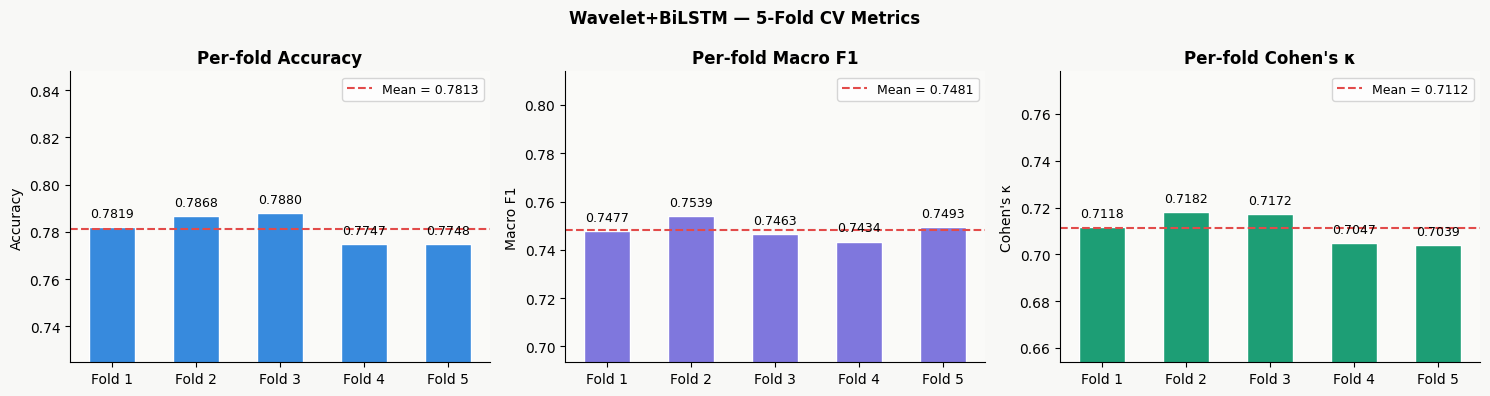

Saved → 04_wlstm_cv_fold_metrics.png


In [57]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 3  |  Per-fold metric bar charts (Acc, Macro F1, κ)
# ════════════════════════════════════════════════════════════════════════════

fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#f8f8f6')

metric_specs = [
    (cv_fold_accs,    'Accuracy',  '#378ADD'),
    (cv_fold_f1s,     'Macro F1',  '#7F77DD'),
    (cv_fold_kappas,  "Cohen's κ", '#1D9E75'),
]
for ax, (vals, label, color) in zip(axes, metric_specs):
    ax.set_facecolor('#fafaf8')
    bars  = ax.bar(fold_labels, vals, color=color, edgecolor='white', width=0.55)
    mean_v = np.mean(vals)
    ax.axhline(mean_v, color='#E24B4A', linewidth=1.5,
               linestyle='--', label=f'Mean = {mean_v:.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Per-fold {label}', fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.06))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Wavelet+BiLSTM — 5-Fold CV Metrics',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_wlstm_cv_fold_metrics.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_wlstm_cv_fold_metrics.png")

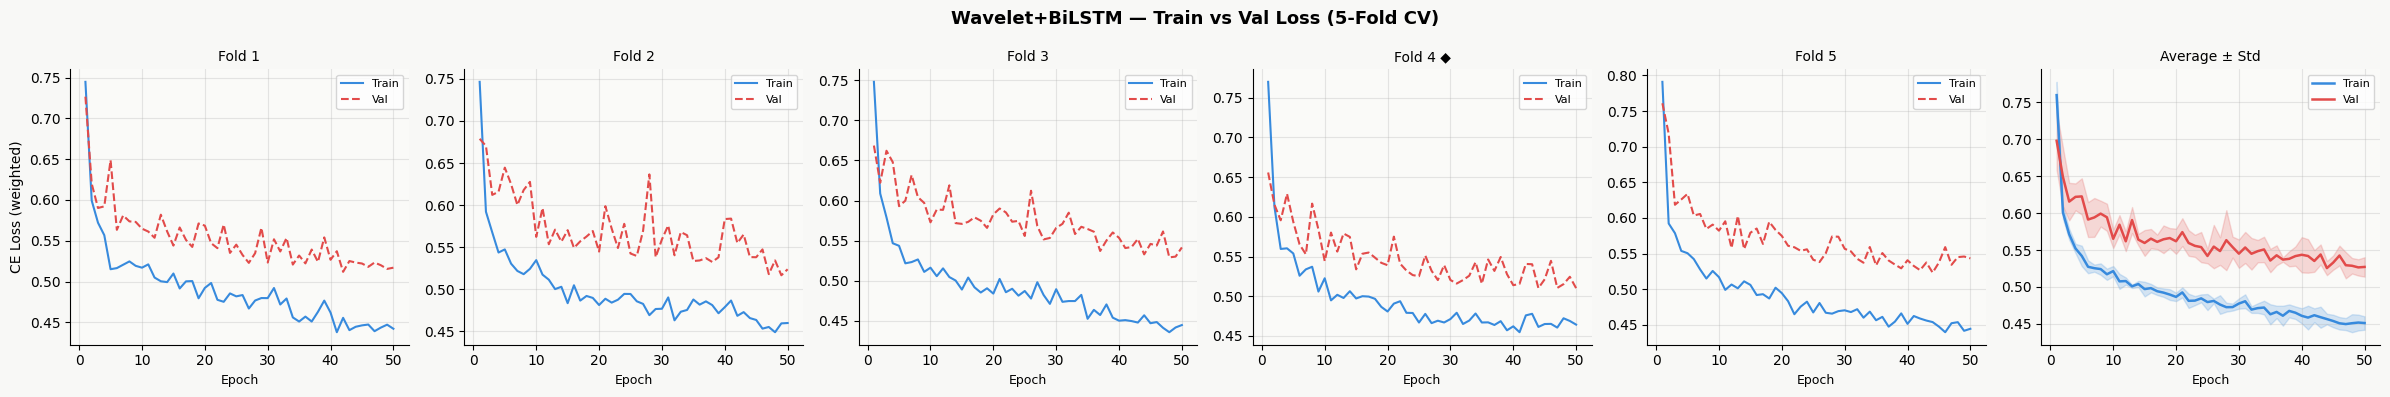

Saved → .\outputs\04_wlstm_cv_fold_loss.png


In [58]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 4  |  Per-fold loss curves (train vs val, 5 folds + avg)
# ════════════════════════════════════════════════════════════════════════════
# ── CELL START ──
best_fold_wlstm = int(np.argmin([vl[-1] for vl in cv_fold_val_losses])) + 1

n_plots = N_FOLDS + 1
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=False)
fig.patch.set_facecolor('#f8f8f6')

for i, ax in enumerate(axes[:N_FOLDS]):
    t_hist = cv_fold_train_losses[i]
    v_hist = cv_fold_val_losses[i]
    ep_range = range(1, len(t_hist) + 1)
    ax.plot(ep_range, t_hist, color='#378ADD', linewidth=1.5, label='Train')
    ax.plot(ep_range, v_hist, color='#E24B4A', linewidth=1.5,
            linestyle='--', label='Val')
    marker = ' ◆' if (i + 1) == best_fold_wlstm else ''
    ax.set_title(f'Fold {i+1}{marker}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    if i == 0:
        ax.set_ylabel('CE Loss (weighted)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_facecolor('#fafaf8')
    ax.spines[['top', 'right']].set_visible(False)

# ── Average ± Std panel ───────────────────────────────────────────────────────
ax_avg = axes[-1]
max_ep = max(len(h) for h in cv_fold_train_losses)

def _pad(lst, length):
    """Pad with last value to align curves of different length."""
    return lst + [lst[-1]] * (length - len(lst))

train_mat = np.array([_pad(h, max_ep) for h in cv_fold_train_losses])
val_mat   = np.array([_pad(h, max_ep) for h in cv_fold_val_losses])
ep_range  = np.arange(1, max_ep + 1)

for mat, color, label in [
    (train_mat, '#378ADD', 'Train'),
    (val_mat,   '#E24B4A', 'Val'),
]:
    mean_ = mat.mean(axis=0)
    std_  = mat.std(axis=0)
    ax_avg.plot(ep_range, mean_, color=color, linewidth=1.8, label=label)
    ax_avg.fill_between(ep_range, mean_ - std_, mean_ + std_,
                        alpha=0.2, color=color)

ax_avg.set_title('Average ± Std', fontsize=10)
ax_avg.set_xlabel('Epoch', fontsize=9)
ax_avg.legend(fontsize=8)
ax_avg.grid(alpha=0.3)
ax_avg.set_facecolor('#fafaf8')
ax_avg.spines[['top', 'right']].set_visible(False)

fig.suptitle('Wavelet+BiLSTM — Train vs Val Loss (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(OUT_DIR, '04_wlstm_cv_fold_loss.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

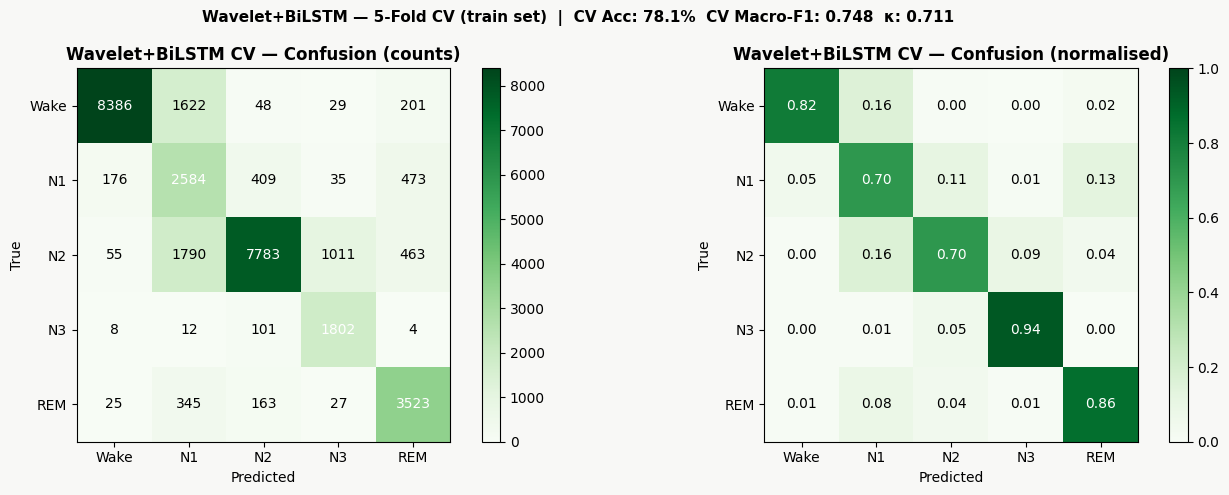

Saved → .\outputs\04_wlstm_cv_confusion.png


In [67]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 6  |  CV confusion matrix (counts + normalised)
# ════════════════════════════════════════════════════════════════════════════

cm_cv_wlstm      = confusion_matrix(_oof_true_arr, _oof_pred_arr,
                                     labels=list(range(5)))
cm_cv_wlstm_norm = (cm_cv_wlstm.astype(float)
                    / cm_cv_wlstm.sum(axis=1, keepdims=True))
tnames = [STAGE_NAMES[s] for s in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_cv_wlstm, cm_cv_wlstm_norm],
        ['Wavelet+BiLSTM CV — Confusion (counts)',
         'Wavelet+BiLSTM CV — Confusion (normalised)'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_cv_wlstm_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(tnames); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, fmt_fn(data[i, j]),
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_cv_wlstm_norm[i, j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

cv_acc_wlstm = np.mean(cv_fold_accs)
cv_f1_wlstm = np.mean(cv_fold_f1s)
cv_kappa_wlstm = np.mean(cv_fold_kappas)

fig.suptitle(
    f'Wavelet+BiLSTM — 5-Fold CV (train set)  |  '
    f'CV Acc: {cv_acc_wlstm*100:.1f}%  CV Macro-F1: {cv_f1_wlstm:.3f}  '
    f'κ: {cv_kappa_wlstm:.3f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, '04_wlstm_cv_confusion.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

In [68]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 7  |  Retrain on full train set
# ════════════════════════════════════════════════════════════════════════════

print("Retraining Wavelet+BiLSTM on full training set...")

# Full-train DataLoader with weighted sampler
flat_tr_full   = y_seq_tr.flatten()
cc_full        = np.bincount(flat_tr_full, minlength=N_CLASSES).astype(float)
cw_full        = 1.0 / (cc_full + 1e-6)
sw_full        = np.array([cw_full[y_seq_tr[i]].mean()
                            for i in range(len(y_seq_tr))])
sampler_full   = WeightedRandomSampler(
    torch.tensor(sw_full, dtype=torch.float32), len(sw_full), replacement=True
)
cw_norm_full   = cw_full / cw_full.sum() * N_CLASSES
cw_tensor_full = torch.tensor(cw_norm_full, dtype=torch.float32).to(DEVICE)

train_loader_full = DataLoader(SeqDataset(X_seq_tr, y_seq_tr),
                                batch_size=32, sampler=sampler_full)
test_loader_full  = DataLoader(SeqDataset(X_seq_te, y_seq_te),
                                batch_size=32, shuffle=False)

# Fresh model
model_wlstm       = WaveletLSTM(input_size=53, proj=64, hidden=128,
                                 num_layers=2, num_classes=5, dropout=0.5).to(DEVICE)
criterion_full    = nn.CrossEntropyLoss(weight=cw_tensor_full)
optimizer_full    = torch.optim.Adam(model_wlstm.parameters(),
                                      lr=1e-3, weight_decay=1e-3)
scheduler_full    = torch.optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer_full, mode='min', factor=0.5, patience=5)

N_EPOCHS_FULL    = 50
PATIENCE_FULL    = 10
best_val_full    = float('inf')
wait_full        = 0
best_state_full  = None
train_losses_wlstm, val_losses_wlstm = [], []

print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Val Loss':>10}")
print("-" * 34)

for epoch in range(1, N_EPOCHS_FULL + 1):
    model_wlstm.train()
    ep_loss, n_b = 0.0, 0
    for X_b, y_b in train_loader_full:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_full.zero_grad()
        loss = criterion_full(model_wlstm(X_b).reshape(-1, N_CLASSES),
                              y_b.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_wlstm.parameters(), 1.0)
        optimizer_full.step()
        ep_loss += loss.item(); n_b += 1

    model_wlstm.eval()
    vl, nv = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader_full:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            vl += criterion_full(model_wlstm(X_b).reshape(-1, N_CLASSES),
                                 y_b.reshape(-1)).item(); nv += 1

    train_losses_wlstm.append(ep_loss / n_b)
    val_losses_wlstm.append(vl / nv)
    scheduler_full.step(val_losses_wlstm[-1])

    if val_losses_wlstm[-1] < best_val_full:
        best_val_full   = val_losses_wlstm[-1]; wait_full = 0
        best_state_full = {k: v.clone() for k, v in model_wlstm.state_dict().items()}
    else:
        wait_full += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_losses_wlstm[-1]:>11.4f} "
              f"| {val_losses_wlstm[-1]:>10.4f}")
    if wait_full >= PATIENCE_FULL:
        print(f"\n  Early stopping at epoch {epoch}")
        break

model_wlstm.load_state_dict(best_state_full)
torch.save(best_state_full, os.path.join(OUT_DIR, 'wavelet_lstm_final.pt'))
print(f"\n  Best val loss: {best_val_full:.4f} — saved → wavelet_lstm_final.pt")

Retraining Wavelet+BiLSTM on full training set...
 Epoch |  Train Loss |   Val Loss
----------------------------------
     1 |      0.7432 |     0.6290
     5 |      0.5228 |     0.5819
    10 |      0.4962 |     0.6072
    15 |      0.5162 |     0.5692
    20 |      0.4971 |     0.5592
    25 |      0.4779 |     0.5425
    30 |      0.4706 |     0.5605

  Early stopping at epoch 34

  Best val loss: 0.5320 — saved → wavelet_lstm_final.pt


In [69]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 8  |  Test evaluation + classification report
# ════════════════════════════════════════════════════════════════════════════

model_wlstm.eval()
all_pred_wlstm, all_true_wlstm = [], []
with torch.no_grad():
    for X_b, y_b in test_loader_full:
        logits = model_wlstm(X_b.to(DEVICE))
        preds  = logits.argmax(dim=-1)
        all_pred_wlstm.append(preds.cpu().numpy().flatten())
        all_true_wlstm.append(y_b.numpy().flatten())

y_pred_wlstm = np.concatenate(all_pred_wlstm)
y_true_wlstm = np.concatenate(all_true_wlstm)

test_acc_wlstm   = accuracy_score(y_true_wlstm, y_pred_wlstm)
test_f1_wlstm    = f1_score(y_true_wlstm, y_pred_wlstm, average='macro')
test_kappa_wlstm = cohen_kappa_score(y_true_wlstm, y_pred_wlstm)

print("Wavelet+BiLSTM — Held-out Test Set")
print("=" * 50)
print(f"  Accuracy  : {test_acc_wlstm*100:.2f}%")
print(f"  Macro F1  : {test_f1_wlstm:.4f}")
print(f"  Cohen's κ : {test_kappa_wlstm:.4f}  ({kappa_label(test_kappa_wlstm)})")
print()
tnames = [STAGE_NAMES[s] for s in range(5)]
print("  Per-class report (test set):")
print(classification_report(y_true_wlstm, y_pred_wlstm,
                             target_names=tnames, digits=4))

Wavelet+BiLSTM — Held-out Test Set
  Accuracy  : 77.46%
  Macro F1  : 0.7539
  Cohen's κ : 0.7065  (Substantial)

  Per-class report (test set):
              precision    recall  f1-score   support

        Wake     0.9578    0.8298    0.8892     12122
          N1     0.3774    0.6638    0.4812      4048
          N2     0.9194    0.6790    0.7812     13481
          N3     0.7691    0.9124    0.8347      3242
         REM     0.6984    0.8918    0.7833      5307

    accuracy                         0.7746     38200
   macro avg     0.7444    0.7954    0.7539     38200
weighted avg     0.8307    0.7746    0.7885     38200



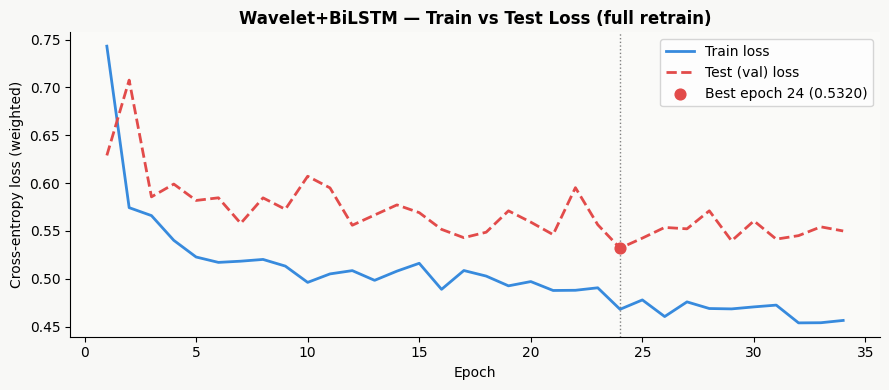

Saved → .\outputs\04_wlstm_train_test_loss.png


In [70]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 9  |  Train vs test loss curve
# ════════════════════════════════════════════════════════════════════════════

epochs_run_wlstm = len(train_losses_wlstm)
ep_range = range(1, epochs_run_wlstm + 1)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f8f8f6')
ax.set_facecolor('#fafaf8')

ax.plot(ep_range, train_losses_wlstm, color='#378ADD', linewidth=2,
        label='Train loss')
ax.plot(ep_range, val_losses_wlstm,   color='#E24B4A', linewidth=2,
        linestyle='--', label='Test (val) loss')

best_ep = int(np.argmin(val_losses_wlstm))
ax.axvline(best_ep + 1, color='gray', linewidth=1, linestyle=':')
ax.scatter(best_ep + 1, val_losses_wlstm[best_ep],
           color='#E24B4A', zorder=5, s=60,
           label=f'Best epoch {best_ep+1} ({val_losses_wlstm[best_ep]:.4f})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss (weighted)')
ax.set_title('Wavelet+BiLSTM — Train vs Test Loss (full retrain)',
             fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

out_path = os.path.join(OUT_DIR, '04_wlstm_train_test_loss.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

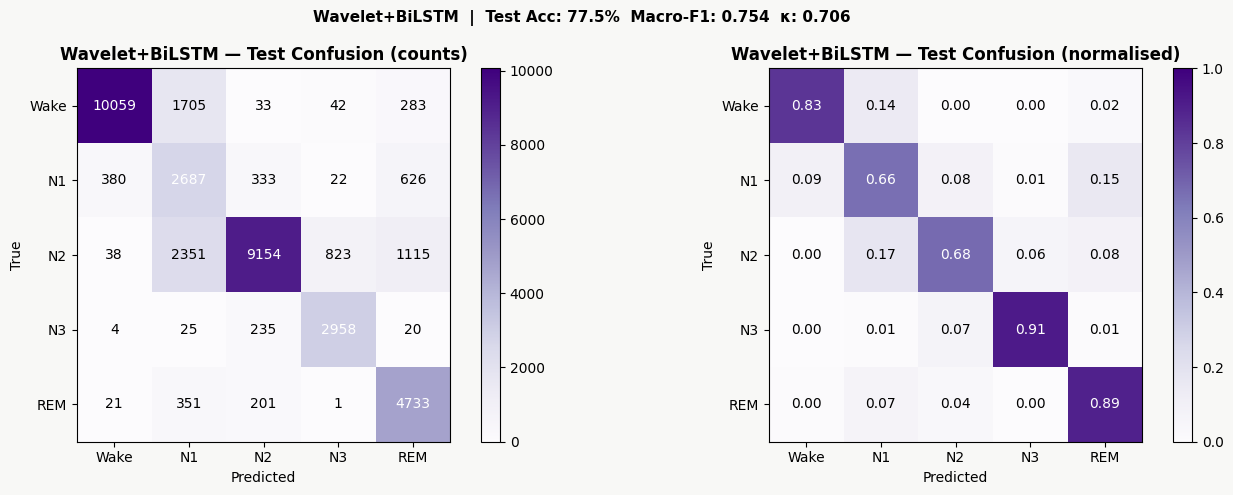

Saved → .\outputs\04_wlstm_test_confusion.png


In [71]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2  — CELL 10  |  Test confusion matrix (counts + normalised)
# ════════════════════════════════════════════════════════════════════════════

cm_wlstm      = confusion_matrix(y_true_wlstm, y_pred_wlstm, labels=list(range(5)))
cm_wlstm_norm = cm_wlstm.astype(float) / cm_wlstm.sum(axis=1, keepdims=True)
tnames        = [STAGE_NAMES[s] for s in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_wlstm, cm_wlstm_norm],
        ['Wavelet+BiLSTM — Test Confusion (counts)',
         'Wavelet+BiLSTM — Test Confusion (normalised)'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_wlstm_norm else None
    im   = ax.imshow(data, cmap='Purples', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(tnames); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, fmt_fn(data[i, j]),
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_wlstm_norm[i, j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Wavelet+BiLSTM  |  '
    f'Test Acc: {test_acc_wlstm*100:.1f}%  '
    f'Macro-F1: {test_f1_wlstm:.3f}  κ: {test_kappa_wlstm:.3f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, '04_wlstm_test_confusion.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

### Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3

In [74]:
# ── Section 2 | Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — 5-Fold Stratified Cross-Validation ──────────────────
# Fresh storage for this trial; all variables are prefixed 't2_' to avoid
# collisions with other trials running in the same kernel session.

N_FOLDS_CV  = 5
N_EPOCHS_CV = 50
LR_CV       = 1e-3
PATIENCE_CV = 10
SEQ_LEN     = 25   # 25-epoch context window (unchanged throughout)

cv_t2_fold_accs,   cv_t2_fold_f1s,  cv_t2_fold_kappas  = [], [], []
cv_t2_fold_tloss,  cv_t2_fold_vloss                      = [], []
_oof_pred_t2,      _oof_true_t2                          = [], []

# Use the middle epoch of each sequence for stratification
y_mid_t2 = y_seq_tr[:, SEQ_LEN // 2]
skf_t2   = StratifiedKFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=42)

print(f"────────────────────────────────────────────────────────────")
print(f"  Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3  —  {N_FOLDS_CV}-Fold CV")
print(f"  LR=1e-3  |  dropout=0.3  |  wd=1e-4  |  epochs≤50")
print(f"────────────────────────────────────────────────────────────")
print(f"  {'{}'.format('Fold'):>5} | {'{}'.format('Acc'):>7} | "
      f"{'{}'.format('Macro F1'):>9} | {'{}'.format(chr(954)):>7}")
print(f"  {'-'*38}")

for fold, (tr_idx, val_idx) in enumerate(skf_t2.split(X_seq_tr, y_mid_t2)):

    # ── Fold data ─────────────────────────────────────────────────────────────
    X_tr_f,  X_val_f = X_seq_tr[tr_idx],  X_seq_tr[val_idx]
    y_tr_f,  y_val_f = y_seq_tr[tr_idx], y_seq_tr[val_idx]

    # Inverse-frequency class weights + weighted random sampler
    flat_f      = y_tr_f.flatten()
    cc_f        = np.bincount(flat_f, minlength=N_CLASSES).astype(float)
    cw_f        = 1.0 / (cc_f + 1e-6)
    sw_f        = np.array([cw_f[y_tr_f[i]].mean() for i in range(len(y_tr_f))])
    sampler_f   = WeightedRandomSampler(
                      torch.tensor(sw_f, dtype=torch.float32),
                      len(sw_f), replacement=True)
    cw_norm_f   = cw_f / cw_f.sum() * N_CLASSES
    cw_tensor_f = torch.tensor(cw_norm_f, dtype=torch.float32).to(DEVICE)

    loader_tr_f  = DataLoader(SeqDataset(X_tr_f,  y_tr_f),
                               batch_size=32, sampler=sampler_f)
    loader_val_f = DataLoader(SeqDataset(X_val_f, y_val_f),
                               batch_size=32, shuffle=False)

    # ── Fresh model + optimiser for this fold ─────────────────────────────────
    mdl_f  = WaveletLSTM(input_size=53, proj=64, hidden=128,
                          num_layers=2, num_classes=5, dropout=0.3).to(DEVICE)
    crit_f = nn.CrossEntropyLoss(weight=cw_tensor_f)
    opt_f  = torch.optim.Adam(mdl_f.parameters(), lr=LR_CV, weight_decay=1e-4)
    sched_f = torch.optim.lr_scheduler.StepLR(opt_f, step_size=10, gamma=0.5)

    best_val_f, wait_f, best_st_f = float('inf'), 0, None
    tl_hist_f, vl_hist_f = [], []   # per-epoch loss history for this fold

    # ── Training loop ──────────────────────────────────────────────────────────
    for epoch in range(1, N_EPOCHS_CV + 1):
        mdl_f.train()
        ep_loss, n_b = 0.0, 0
        for X_b, y_b in loader_tr_f:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_f.zero_grad()
            out  = mdl_f(X_b).reshape(-1, N_CLASSES)
            loss = crit_f(out, y_b.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(mdl_f.parameters(), 1.0)
            opt_f.step()
            ep_loss += loss.item(); n_b += 1

        mdl_f.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in loader_val_f:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vl += crit_f(mdl_f(X_b).reshape(-1, N_CLASSES),
                             y_b.reshape(-1)).item(); nv += 1

        tl_hist_f.append(ep_loss / n_b)
        vl_hist_f.append(vl / nv)
        sched_f.step()   # StepLR advances on every epoch regardless of val loss

        if vl_hist_f[-1] < best_val_f:
            best_val_f = vl_hist_f[-1]; wait_f = 0
            best_st_f  = {k: v.clone() for k, v in mdl_f.state_dict().items()}
        else:
            wait_f += 1
        if wait_f >= PATIENCE_CV:
            break

    # ── Store per-fold loss curves (after all epochs) ─────────────────────────
    cv_t2_fold_tloss.append(tl_hist_f)
    cv_t2_fold_vloss.append(vl_hist_f)

    # ── Evaluate on the held-out fold ──────────────────────────────────────────
    mdl_f.load_state_dict(best_st_f)
    mdl_f.eval()
    preds_f, trues_f = [], []
    with torch.no_grad():
        for X_b, y_b in loader_val_f:
            p = mdl_f(X_b.to(DEVICE)).argmax(dim=-1)
            preds_f.append(p.cpu().numpy().flatten())
            trues_f.append(y_b.numpy().flatten())
    preds_f = np.concatenate(preds_f)
    trues_f = np.concatenate(trues_f)

    acc_f   = accuracy_score(trues_f, preds_f)
    f1_f    = f1_score(trues_f, preds_f, average='macro')
    kappa_f = cohen_kappa_score(trues_f, preds_f)

    cv_t2_fold_accs.append(acc_f);   cv_t2_fold_f1s.append(f1_f)
    cv_t2_fold_kappas.append(kappa_f)
    _oof_pred_t2.extend(preds_f.tolist())
    _oof_true_t2.extend(trues_f.tolist())

    print(f"  {fold+1:>5} | {acc_f*100:>6.2f}% | {f1_f:>9.4f} | {kappa_f:>7.4f}")

print(f"  {'-'*38}")
print(f"  Mean  | {np.mean(cv_t2_fold_accs)*100:>6.2f}% | "
      f"{np.mean(cv_t2_fold_f1s):>9.4f} | {np.mean(cv_t2_fold_kappas):>7.4f}")
print(f"  ±Std  | {np.std(cv_t2_fold_accs)*100:>6.2f}%   | "
      f"{np.std(cv_t2_fold_f1s):>9.4f} | {np.std(cv_t2_fold_kappas):>7.4f}")

# Aggregate OOF arrays for the CV-level confusion matrix and classification report
_oof_pred_t2_arr = np.array(_oof_pred_t2, dtype=np.int64)
_oof_true_t2_arr = np.array(_oof_true_t2, dtype=np.int64)


────────────────────────────────────────────────────────────
  Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3  —  5-Fold CV
  LR=1e-3  |  dropout=0.3  |  wd=1e-4  |  epochs≤50
────────────────────────────────────────────────────────────
   Fold |     Acc |  Macro F1 |       κ
  --------------------------------------
      1 |  79.23% |    0.7596 |  0.7248
      2 |  78.37% |    0.7573 |  0.7161
      3 |  79.71% |    0.7637 |  0.7289
      4 |  79.76% |    0.7735 |  0.7337
      5 |  79.58% |    0.7680 |  0.7298
  --------------------------------------
  Mean  |  79.33% |    0.7644 |  0.7267
  ±Std  |   0.51%   |    0.0058 |  0.0060


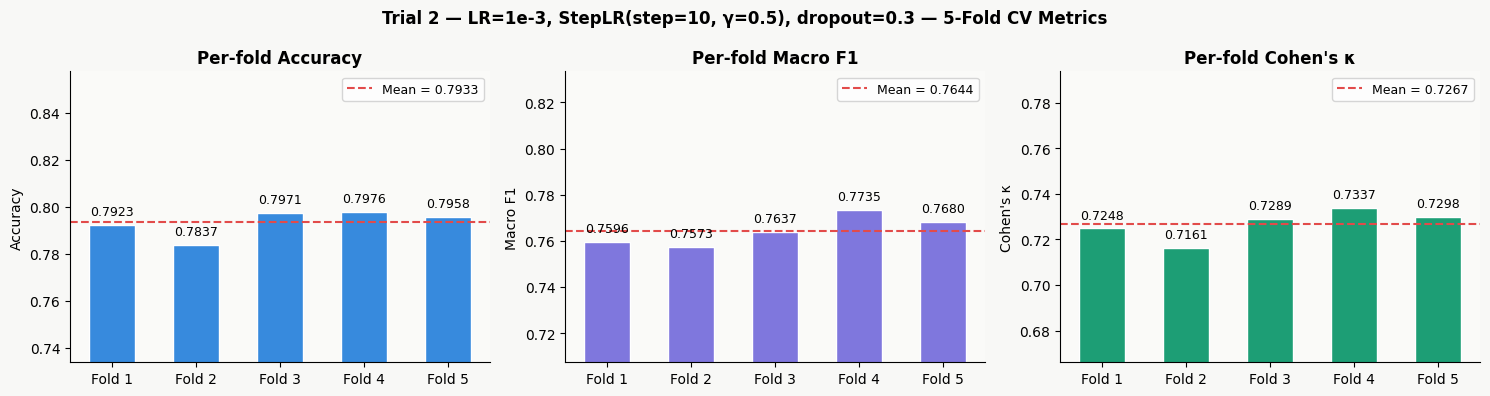

Saved → 04_t2_cv_fold_metrics.png


In [75]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Per-fold bar charts: Accuracy, Macro F1, Cohen's κ ─────────────
fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS_CV)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#f8f8f6')

for ax, (vals, metric_name, color) in zip(axes, [
    (cv_t2_fold_accs,   'Accuracy',   '#378ADD'),
    (cv_t2_fold_f1s,    'Macro F1',   '#7F77DD'),
    (cv_t2_fold_kappas, "Cohen's κ",  '#1D9E75'),
]):
    ax.set_facecolor('#fafaf8')
    bars   = ax.bar(fold_labels, vals, color=color, edgecolor='white', width=0.55)
    mean_v = np.mean(vals)
    ax.axhline(mean_v, color='#E24B4A', linewidth=1.5,
               linestyle='--', label=f'Mean = {mean_v:.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Per-fold {metric_name}', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.06))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — 5-Fold CV Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t2_cv_fold_metrics.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t2_cv_fold_metrics.png")


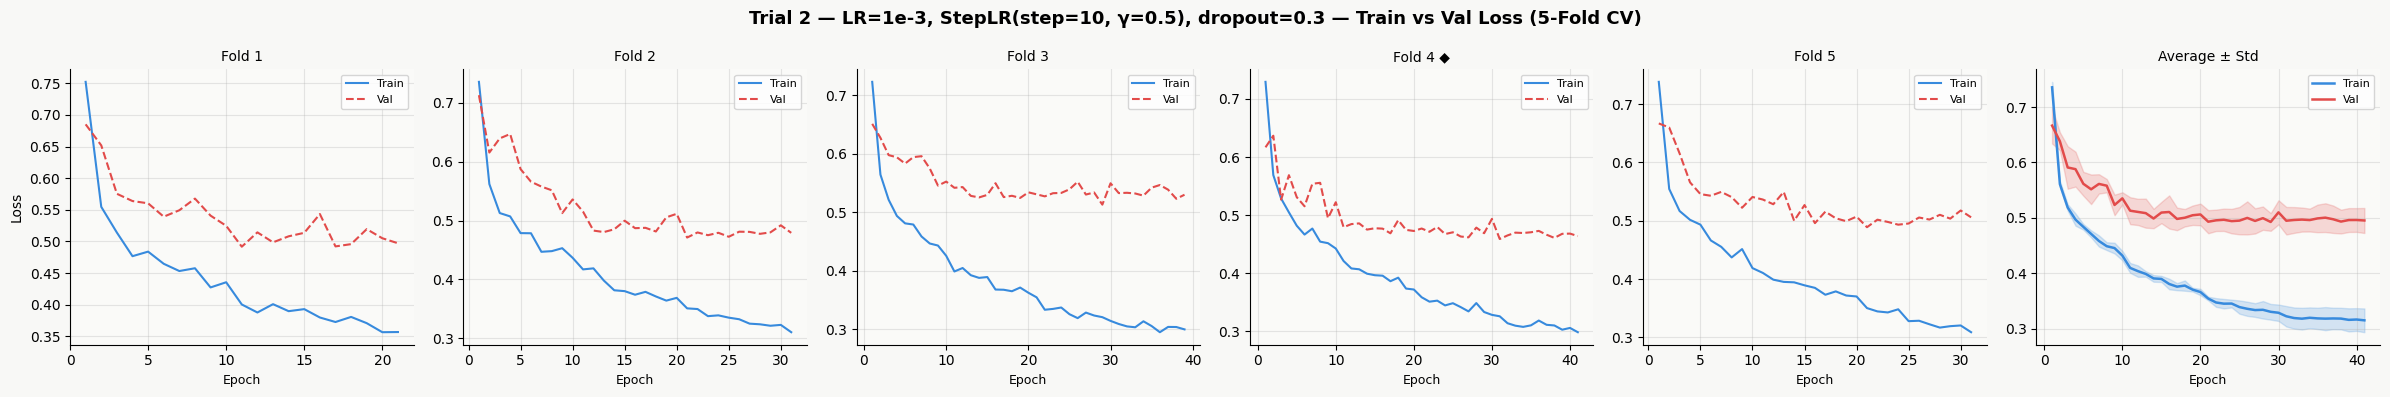

Saved → 04_t2_cv_fold_loss.png


In [76]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs Val loss curves (5 folds + mean±std panel) ────────────
def _pad(lst, length):
    """Right-pad a list with its last value so curves align to the same length."""
    return lst + [lst[-1]] * (length - len(lst))

best_fold_t2 = int(np.argmin([h[-1] for h in cv_t2_fold_vloss])) + 1
n_panels      = N_FOLDS_CV + 1   # one per fold + one average panel

fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
fig.patch.set_facecolor('#f8f8f6')

for i, ax in enumerate(axes[:N_FOLDS_CV]):
    marker = ' ◆' if (i + 1) == best_fold_t2 else ''
    ep_range = range(1, len(cv_t2_fold_tloss[i]) + 1)
    ax.plot(ep_range, cv_t2_fold_tloss[i], color='#378ADD', linewidth=1.5, label='Train')
    ax.plot(ep_range, cv_t2_fold_vloss[i], color='#E24B4A', linewidth=1.5,
            linestyle='--', label='Val')
    ax.set_title(f'Fold {i+1}{marker}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_facecolor('#fafaf8')
    ax.spines[['top', 'right']].set_visible(False)

# Average ± std panel
ax_avg    = axes[-1]
max_ep    = max(len(h) for h in cv_t2_fold_tloss)
train_mat = np.array([_pad(h, max_ep) for h in cv_t2_fold_tloss])
val_mat   = np.array([_pad(h, max_ep) for h in cv_t2_fold_vloss])
ep_arr    = np.arange(1, max_ep + 1)

for mat, color, lbl in [(train_mat, '#378ADD', 'Train'), (val_mat, '#E24B4A', 'Val')]:
    m, s = mat.mean(axis=0), mat.std(axis=0)
    ax_avg.plot(ep_arr, m, color=color, linewidth=1.8, label=lbl)
    ax_avg.fill_between(ep_arr, m - s, m + s, alpha=0.2, color=color)

ax_avg.set_title('Average ± Std', fontsize=10)
ax_avg.set_xlabel('Epoch', fontsize=9)
ax_avg.legend(fontsize=8); ax_avg.grid(alpha=0.3); ax_avg.set_facecolor('#fafaf8')
ax_avg.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs Val Loss (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t2_cv_fold_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t2_cv_fold_loss.png")


In [77]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — CV summary + OOF classification report ─────────────────────────
cv_acc_t2   = accuracy_score(_oof_true_t2_arr, _oof_pred_t2_arr)
cv_f1_t2    = f1_score(_oof_true_t2_arr, _oof_pred_t2_arr, average='macro')
cv_kappa_t2 = cohen_kappa_score(_oof_true_t2_arr, _oof_pred_t2_arr)

print(f"{' Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — CV Summary ':═^65}")
print(f"  OOF Accuracy  : {cv_acc_t2*100:.2f}%")
print(f"  OOF Macro F1  : {cv_f1_t2:.4f}")
print(f"  OOF Cohen's κ : {cv_kappa_t2:.4f}  ({kappa_label(cv_kappa_t2)})")
print(f"  Per-fold Acc  : {np.mean(cv_t2_fold_accs)*100:.2f}%"
      f" ± {np.std(cv_t2_fold_accs)*100:.2f}%")
print(f"  Per-fold F1   : {np.mean(cv_t2_fold_f1s):.4f}"
      f" ± {np.std(cv_t2_fold_f1s):.4f}")
print(f"  Per-fold κ    : {np.mean(cv_t2_fold_kappas):.4f}"
      f" ± {np.std(cv_t2_fold_kappas):.4f}")
print()
tnames = [STAGE_NAMES[s] for s in range(5)]
print(classification_report(_oof_true_t2_arr, _oof_pred_t2_arr,
                             target_names=tnames, digits=4))


 Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — CV Summary 
  OOF Accuracy  : 79.33%
  OOF Macro F1  : 0.7644
  OOF Cohen's κ : 0.7267  (Substantial)
  Per-fold Acc  : 79.33% ± 0.51%
  Per-fold F1   : 0.7644 ± 0.0058
  Per-fold κ    : 0.7267 ± 0.0060

              precision    recall  f1-score   support

        Wake     0.9653    0.8564    0.9076     52041
          N1     0.4257    0.7091    0.5321     17462
          N2     0.9261    0.7039    0.7998     55647
          N3     0.6553    0.9354    0.7707      9797
         REM     0.7541    0.8795    0.8120     20528

    accuracy                         0.7933    155475
   macro avg     0.7453    0.8169    0.7644    155475
weighted avg     0.8433    0.7933    0.8056    155475



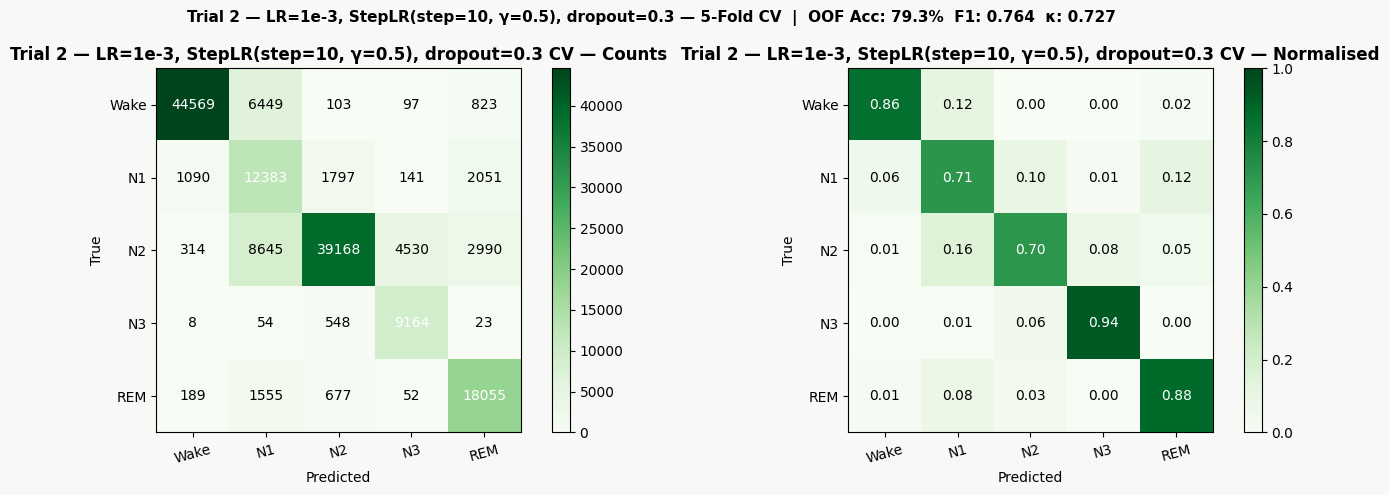

Saved → 04_t2_cv_confusion.png


In [78]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — CV confusion matrix (counts + row-normalised) ──────────────────
cm_cv_t2      = confusion_matrix(_oof_true_t2_arr, _oof_pred_t2_arr,
                                   labels=list(range(N_CLASSES)))
cm_cv_t2_norm = cm_cv_t2.astype(float) / cm_cv_t2.sum(axis=1, keepdims=True)
tnames         = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_cv_t2, cm_cv_t2_norm],
        ['Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 CV — Counts', 'Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 CV — Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_cv_t2_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_cv_t2_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — 5-Fold CV  |  '
    f'OOF Acc: {cv_acc_t2*100:.1f}%  F1: {cv_f1_t2:.3f}  κ: {cv_kappa_t2:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t2_cv_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t2_cv_confusion.png")


In [79]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Retrain on full training set ────────────────────────────────────
# The CV loop above used 80% of the training data per fold.  Here we retrain
# a fresh model on *all* training sequences so the final weights see every
# available labelled epoch before test evaluation.
print(f"{' Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Full retrain ':─^60}")

# Class-weighted sampler over the complete training split
flat_full      = y_seq_tr.flatten()
cc_full        = np.bincount(flat_full, minlength=N_CLASSES).astype(float)
cw_full        = 1.0 / (cc_full + 1e-6)
sw_full        = np.array([cw_full[y_seq_tr[i]].mean()
                            for i in range(len(y_seq_tr))])
sampler_full   = WeightedRandomSampler(
                     torch.tensor(sw_full, dtype=torch.float32),
                     len(sw_full), replacement=True)
cw_norm_full   = cw_full / cw_full.sum() * N_CLASSES
cw_tensor_full = torch.tensor(cw_norm_full, dtype=torch.float32).to(DEVICE)

train_loader_t2 = DataLoader(SeqDataset(X_seq_tr, y_seq_tr),
                                batch_size=32, sampler=sampler_full)
test_loader_t2  = DataLoader(SeqDataset(X_seq_te, y_seq_te),
                                batch_size=32, shuffle=False)

# Fresh model — same architecture and hyper-parameters used in the CV loop
model_t2     = WaveletLSTM(input_size=53, proj=64, hidden=128,
                             num_layers=2, num_classes=5,
                             dropout=0.3).to(DEVICE)
criterion_t2 = nn.CrossEntropyLoss(weight=cw_tensor_full)
optimizer_t2 = torch.optim.Adam(model_t2.parameters(),
                                  lr=1e-3, weight_decay=1e-4)
scheduler_t2 = torch.optim.lr_scheduler.StepLR(optimizer_t2, step_size=10, gamma=0.5)

N_EPOCHS_FULL = 60
PATIENCE_FULL = 10
best_val_t2, wait_t2, best_state_t2 = float('inf'), 0, None
train_losses_t2, val_losses_t2       = [], []

print(f"  Epoch  | Train Loss  | Val Loss")
print(f"  ----------------------------------")

for epoch in range(1, N_EPOCHS_FULL + 1):
    model_t2.train()
    ep_loss, n_b = 0.0, 0
    for X_b, y_b in train_loader_t2:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_t2.zero_grad()
        loss = criterion_t2(model_t2(X_b).reshape(-1, N_CLASSES), y_b.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_t2.parameters(), 1.0)
        optimizer_t2.step()
        ep_loss += loss.item(); n_b += 1

    model_t2.eval()
    vl, nv = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader_t2:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            vl += criterion_t2(model_t2(X_b).reshape(-1, N_CLASSES),
                                 y_b.reshape(-1)).item(); nv += 1

    train_losses_t2.append(ep_loss / n_b)
    val_losses_t2.append(vl / nv)
    scheduler_t2.step()   # StepLR — epoch-based, no val metric needed

    if val_losses_t2[-1] < best_val_t2:
        best_val_t2   = val_losses_t2[-1]; wait_t2 = 0
        best_state_t2 = {k: v.clone() for k, v in model_t2.state_dict().items()}
    else:
        wait_t2 += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:>5}  | {train_losses_t2[-1]:>11.4f} | {val_losses_t2[-1]:>9.4f}")
    if wait_t2 >= PATIENCE_FULL:
        print(f"\n  Early stop at epoch {epoch} (no improvement for {PATIENCE_FULL} epochs)")
        break

model_t2.load_state_dict(best_state_t2)
torch.save(best_state_t2, os.path.join(OUT_DIR, '04_t2_model.pt'))
print(f"\n  Best val loss: {best_val_t2:.4f} — weights saved.")


 Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Full retrain 
  Epoch  | Train Loss  | Val Loss
  ----------------------------------
      1  |      0.6867 |    0.6133
      5  |      0.4623 |    0.5432
     10  |      0.4290 |    0.5458
     15  |      0.3859 |    0.5322
     20  |      0.3703 |    0.5039
     25  |      0.3397 |    0.5103
     30  |      0.3173 |    0.5358

  Early stop at epoch 30 (no improvement for 10 epochs)

  Best val loss: 0.5039 — weights saved.


In [80]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Held-out test evaluation + classification report ────────────────
model_t2.eval()
preds_list_t2, trues_list_t2 = [], []
with torch.no_grad():
    for X_b, y_b in test_loader_t2:
        logits = model_t2(X_b.to(DEVICE))
        preds_list_t2.append(logits.argmax(dim=-1).cpu().numpy().flatten())
        trues_list_t2.append(y_b.numpy().flatten())

y_pred_t2 = np.concatenate(preds_list_t2)
y_true_t2 = np.concatenate(trues_list_t2)

test_acc_t2   = accuracy_score(y_true_t2, y_pred_t2)
test_f1_t2    = f1_score(y_true_t2, y_pred_t2, average='macro')
test_kappa_t2 = cohen_kappa_score(y_true_t2, y_pred_t2)

print(f"{' Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Test Results ':═^60}")
print(f"  Accuracy  : {test_acc_t2*100:.2f}%")
print(f"  Macro F1  : {test_f1_t2:.4f}")
print(f"  Cohen's κ : {test_kappa_t2:.4f}  ({kappa_label(test_kappa_t2)})")
print()
tnames = [STAGE_NAMES[s] for s in range(N_CLASSES)]
print(classification_report(y_true_t2, y_pred_t2, target_names=tnames, digits=4))


 Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Test Results 
  Accuracy  : 79.74%
  Macro F1  : 0.7733
  Cohen's κ : 0.7341  (Substantial)

              precision    recall  f1-score   support

        Wake     0.9598    0.8291    0.8897     12122
          N1     0.4212    0.6759    0.5190      4048
          N2     0.9126    0.7404    0.8176     13481
          N3     0.7753    0.9044    0.8349      3242
         REM     0.7309    0.8971    0.8055      5307

    accuracy                         0.7974     38200
   macro avg     0.7600    0.8094    0.7733     38200
weighted avg     0.8386    0.7974    0.8086     38200



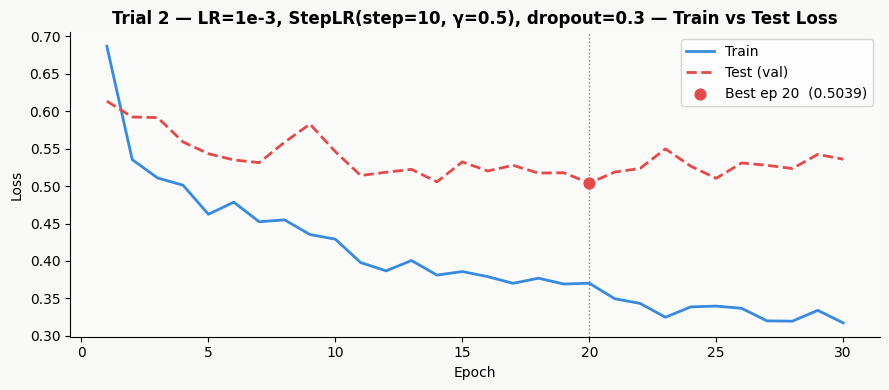

Saved → 04_t2_train_test_loss.png


In [81]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs test loss (full retrain run) ──────────────────────────
ep_range = range(1, len(train_losses_t2) + 1)
best_ep  = int(np.argmin(val_losses_t2))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f8f8f6'); ax.set_facecolor('#fafaf8')

ax.plot(ep_range, train_losses_t2, color='#378ADD', linewidth=2, label='Train')
ax.plot(ep_range, val_losses_t2,   color='#E24B4A', linewidth=2,
        linestyle='--', label='Test (val)')
ax.axvline(best_ep + 1, color='gray', linewidth=1, linestyle=':')
ax.scatter(best_ep + 1, val_losses_t2[best_ep], color='#E24B4A', zorder=5, s=60,
           label=f'Best ep {best_ep+1}  ({val_losses_t2[best_ep]:.4f})')

ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs Test Loss', fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t2_train_test_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t2_train_test_loss.png")


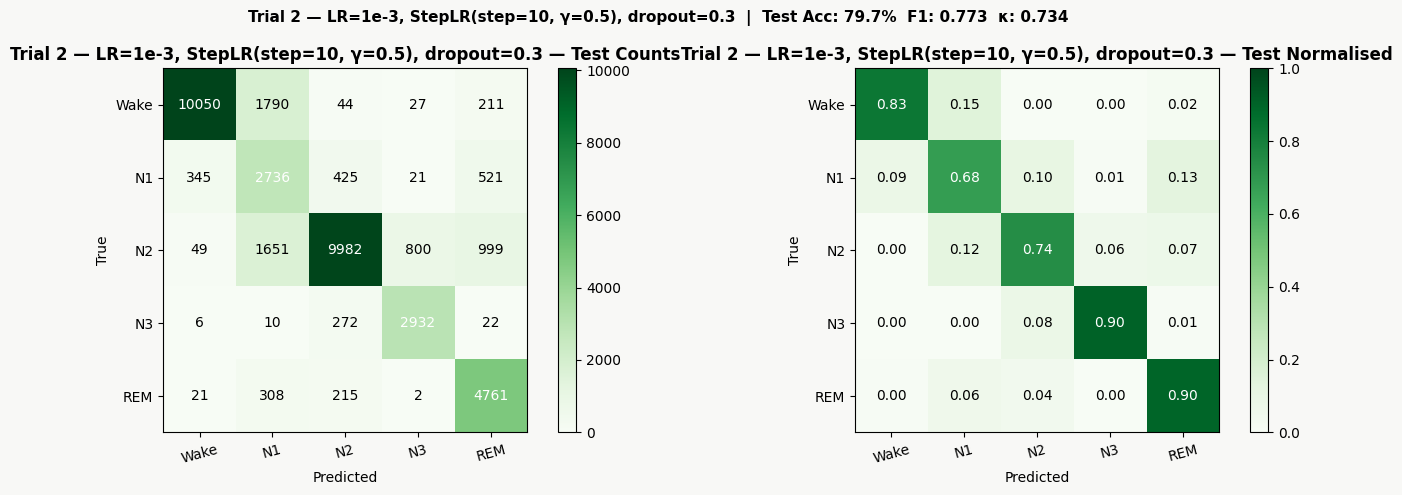

Saved → 04_t2_test_confusion.png


In [82]:
# ── Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Test confusion matrix (counts + row-normalised) ────────────────
cm_t2      = confusion_matrix(y_true_t2, y_pred_t2, labels=list(range(N_CLASSES)))
cm_t2_norm = cm_t2.astype(float) / cm_t2.sum(axis=1, keepdims=True)
tnames      = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_t2, cm_t2_norm],
        ['Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Test Counts', 'Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3 — Test Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_t2_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_t2_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Trial 2 — LR=1e-3, StepLR(step=10, γ=0.5), dropout=0.3  |  '
    f'Test Acc: {test_acc_t2*100:.1f}%  F1: {test_f1_t2:.3f}  κ: {test_kappa_t2:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t2_test_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t2_test_confusion.png")


### Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3

In [84]:
# ── Section 2 | Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — 5-Fold Stratified Cross-Validation ──────────────────
# Fresh storage for this trial; all variables are prefixed 't3_' to avoid
# collisions with other trials running in the same kernel session.

N_FOLDS_CV  = 5
N_EPOCHS_CV = 50
LR_CV       = 1e-2
PATIENCE_CV = 10
SEQ_LEN     = 25   # 25-epoch context window (unchanged throughout)

cv_t3_fold_accs,   cv_t3_fold_f1s,  cv_t3_fold_kappas  = [], [], []
cv_t3_fold_tloss,  cv_t3_fold_vloss                      = [], []
_oof_pred_t3,      _oof_true_t3                          = [], []

# Use the middle epoch of each sequence for stratification
y_mid_t3 = y_seq_tr[:, SEQ_LEN // 2]
skf_t3   = StratifiedKFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=42)

print(f"────────────────────────────────────────────────────────────")
print(f"  Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3  —  {N_FOLDS_CV}-Fold CV")
print(f"  LR=1e-2  |  dropout=0.3  |  wd=1e-4  |  epochs≤50")
print(f"────────────────────────────────────────────────────────────")
print(f"  {'{}'.format('Fold'):>5} | {'{}'.format('Acc'):>7} | "
      f"{'{}'.format('Macro F1'):>9} | {'{}'.format(chr(954)):>7}")
print(f"  {'-'*38}")

for fold, (tr_idx, val_idx) in enumerate(skf_t3.split(X_seq_tr, y_mid_t3)):

    # ── Fold data ─────────────────────────────────────────────────────────────
    X_tr_f,  X_val_f = X_seq_tr[tr_idx],  X_seq_tr[val_idx]
    y_tr_f,  y_val_f = y_seq_tr[tr_idx], y_seq_tr[val_idx]

    # Inverse-frequency class weights + weighted random sampler
    flat_f      = y_tr_f.flatten()
    cc_f        = np.bincount(flat_f, minlength=N_CLASSES).astype(float)
    cw_f        = 1.0 / (cc_f + 1e-6)
    sw_f        = np.array([cw_f[y_tr_f[i]].mean() for i in range(len(y_tr_f))])
    sampler_f   = WeightedRandomSampler(
                      torch.tensor(sw_f, dtype=torch.float32),
                      len(sw_f), replacement=True)
    cw_norm_f   = cw_f / cw_f.sum() * N_CLASSES
    cw_tensor_f = torch.tensor(cw_norm_f, dtype=torch.float32).to(DEVICE)

    loader_tr_f  = DataLoader(SeqDataset(X_tr_f,  y_tr_f),
                               batch_size=32, sampler=sampler_f)
    loader_val_f = DataLoader(SeqDataset(X_val_f, y_val_f),
                               batch_size=32, shuffle=False)

    # ── Fresh model + optimiser for this fold ─────────────────────────────────
    mdl_f  = WaveletLSTM(input_size=53, proj=64, hidden=128,
                          num_layers=2, num_classes=5, dropout=0.3).to(DEVICE)
    crit_f = nn.CrossEntropyLoss(weight=cw_tensor_f)
    opt_f  = torch.optim.Adam(mdl_f.parameters(), lr=LR_CV, weight_decay=1e-4)
    sched_f = torch.optim.lr_scheduler.StepLR(opt_f, step_size=10, gamma=0.5)

    best_val_f, wait_f, best_st_f = float('inf'), 0, None
    tl_hist_f, vl_hist_f = [], []   # per-epoch loss history for this fold

    # ── Training loop ──────────────────────────────────────────────────────────
    for epoch in range(1, N_EPOCHS_CV + 1):
        mdl_f.train()
        ep_loss, n_b = 0.0, 0
        for X_b, y_b in loader_tr_f:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_f.zero_grad()
            out  = mdl_f(X_b).reshape(-1, N_CLASSES)
            loss = crit_f(out, y_b.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(mdl_f.parameters(), 1.0)
            opt_f.step()
            ep_loss += loss.item(); n_b += 1

        mdl_f.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in loader_val_f:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vl += crit_f(mdl_f(X_b).reshape(-1, N_CLASSES),
                             y_b.reshape(-1)).item(); nv += 1

        tl_hist_f.append(ep_loss / n_b)
        vl_hist_f.append(vl / nv)
        sched_f.step()   # StepLR advances on every epoch regardless of val loss

        if vl_hist_f[-1] < best_val_f:
            best_val_f = vl_hist_f[-1]; wait_f = 0
            best_st_f  = {k: v.clone() for k, v in mdl_f.state_dict().items()}
        else:
            wait_f += 1
        if wait_f >= PATIENCE_CV:
            break

    # ── Store per-fold loss curves (after all epochs) ─────────────────────────
    cv_t3_fold_tloss.append(tl_hist_f)
    cv_t3_fold_vloss.append(vl_hist_f)

    # ── Evaluate on the held-out fold ──────────────────────────────────────────
    mdl_f.load_state_dict(best_st_f)
    mdl_f.eval()
    preds_f, trues_f = [], []
    with torch.no_grad():
        for X_b, y_b in loader_val_f:
            p = mdl_f(X_b.to(DEVICE)).argmax(dim=-1)
            preds_f.append(p.cpu().numpy().flatten())
            trues_f.append(y_b.numpy().flatten())
    preds_f = np.concatenate(preds_f)
    trues_f = np.concatenate(trues_f)

    acc_f   = accuracy_score(trues_f, preds_f)
    f1_f    = f1_score(trues_f, preds_f, average='macro')
    kappa_f = cohen_kappa_score(trues_f, preds_f)

    cv_t3_fold_accs.append(acc_f);   cv_t3_fold_f1s.append(f1_f)
    cv_t3_fold_kappas.append(kappa_f)
    _oof_pred_t3.extend(preds_f.tolist())
    _oof_true_t3.extend(trues_f.tolist())

    print(f"  {fold+1:>5} | {acc_f*100:>6.2f}% | {f1_f:>9.4f} | {kappa_f:>7.4f}")

print(f"  {'-'*38}")
print(f"  Mean  | {np.mean(cv_t3_fold_accs)*100:>6.2f}% | "
      f"{np.mean(cv_t3_fold_f1s):>9.4f} | {np.mean(cv_t3_fold_kappas):>7.4f}")
print(f"  ±Std  | {np.std(cv_t3_fold_accs)*100:>6.2f}%   | "
      f"{np.std(cv_t3_fold_f1s):>9.4f} | {np.std(cv_t3_fold_kappas):>7.4f}")

# Aggregate OOF arrays for the CV-level confusion matrix and classification report
_oof_pred_t3_arr = np.array(_oof_pred_t3, dtype=np.int64)
_oof_true_t3_arr = np.array(_oof_true_t3, dtype=np.int64)


────────────────────────────────────────────────────────────
  Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3  —  5-Fold CV
  LR=1e-2  |  dropout=0.3  |  wd=1e-4  |  epochs≤50
────────────────────────────────────────────────────────────
   Fold |     Acc |  Macro F1 |       κ
  --------------------------------------
      1 |  79.23% |    0.7537 |  0.7243
      2 |  78.97% |    0.7623 |  0.7232
      3 |  77.98% |    0.7472 |  0.7075
      4 |  79.64% |    0.7687 |  0.7322
      5 |  78.20% |    0.7556 |  0.7137
  --------------------------------------
  Mean  |  78.81% |    0.7575 |  0.7202
  ±Std  |   0.62%   |    0.0074 |  0.0086


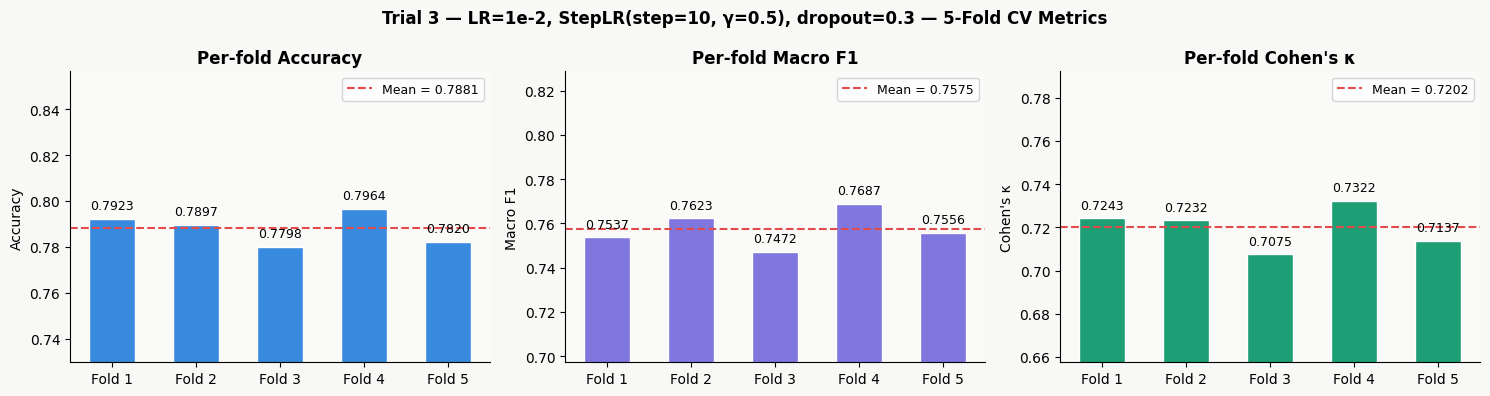

Saved → 04_t3_cv_fold_metrics.png


In [85]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Per-fold bar charts: Accuracy, Macro F1, Cohen's κ ─────────────
fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS_CV)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#f8f8f6')

for ax, (vals, metric_name, color) in zip(axes, [
    (cv_t3_fold_accs,   'Accuracy',   '#378ADD'),
    (cv_t3_fold_f1s,    'Macro F1',   '#7F77DD'),
    (cv_t3_fold_kappas, "Cohen's κ",  '#1D9E75'),
]):
    ax.set_facecolor('#fafaf8')
    bars   = ax.bar(fold_labels, vals, color=color, edgecolor='white', width=0.55)
    mean_v = np.mean(vals)
    ax.axhline(mean_v, color='#E24B4A', linewidth=1.5,
               linestyle='--', label=f'Mean = {mean_v:.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Per-fold {metric_name}', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.06))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — 5-Fold CV Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t3_cv_fold_metrics.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t3_cv_fold_metrics.png")


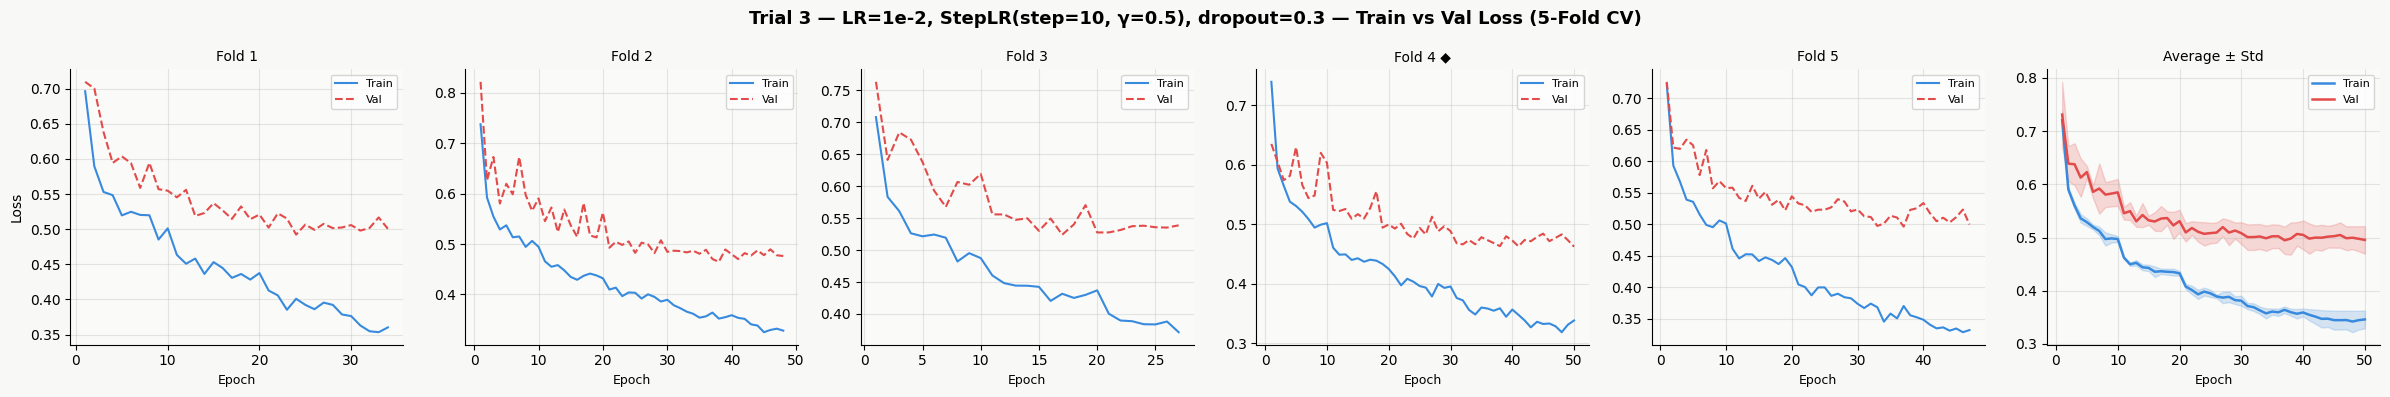

Saved → 04_t3_cv_fold_loss.png


In [86]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs Val loss curves (5 folds + mean±std panel) ────────────
def _pad(lst, length):
    """Right-pad a list with its last value so curves align to the same length."""
    return lst + [lst[-1]] * (length - len(lst))

best_fold_t3 = int(np.argmin([h[-1] for h in cv_t3_fold_vloss])) + 1
n_panels      = N_FOLDS_CV + 1   # one per fold + one average panel

fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
fig.patch.set_facecolor('#f8f8f6')

for i, ax in enumerate(axes[:N_FOLDS_CV]):
    marker = ' ◆' if (i + 1) == best_fold_t3 else ''
    ep_range = range(1, len(cv_t3_fold_tloss[i]) + 1)
    ax.plot(ep_range, cv_t3_fold_tloss[i], color='#378ADD', linewidth=1.5, label='Train')
    ax.plot(ep_range, cv_t3_fold_vloss[i], color='#E24B4A', linewidth=1.5,
            linestyle='--', label='Val')
    ax.set_title(f'Fold {i+1}{marker}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_facecolor('#fafaf8')
    ax.spines[['top', 'right']].set_visible(False)

# Average ± std panel
ax_avg    = axes[-1]
max_ep    = max(len(h) for h in cv_t3_fold_tloss)
train_mat = np.array([_pad(h, max_ep) for h in cv_t3_fold_tloss])
val_mat   = np.array([_pad(h, max_ep) for h in cv_t3_fold_vloss])
ep_arr    = np.arange(1, max_ep + 1)

for mat, color, lbl in [(train_mat, '#378ADD', 'Train'), (val_mat, '#E24B4A', 'Val')]:
    m, s = mat.mean(axis=0), mat.std(axis=0)
    ax_avg.plot(ep_arr, m, color=color, linewidth=1.8, label=lbl)
    ax_avg.fill_between(ep_arr, m - s, m + s, alpha=0.2, color=color)

ax_avg.set_title('Average ± Std', fontsize=10)
ax_avg.set_xlabel('Epoch', fontsize=9)
ax_avg.legend(fontsize=8); ax_avg.grid(alpha=0.3); ax_avg.set_facecolor('#fafaf8')
ax_avg.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs Val Loss (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t3_cv_fold_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t3_cv_fold_loss.png")


In [87]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — CV summary + OOF classification report ─────────────────────────
cv_acc_t3   = accuracy_score(_oof_true_t3_arr, _oof_pred_t3_arr)
cv_f1_t3    = f1_score(_oof_true_t3_arr, _oof_pred_t3_arr, average='macro')
cv_kappa_t3 = cohen_kappa_score(_oof_true_t3_arr, _oof_pred_t3_arr)

print(f"{' Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — CV Summary ':═^65}")
print(f"  OOF Accuracy  : {cv_acc_t3*100:.2f}%")
print(f"  OOF Macro F1  : {cv_f1_t3:.4f}")
print(f"  OOF Cohen's κ : {cv_kappa_t3:.4f}  ({kappa_label(cv_kappa_t3)})")
print(f"  Per-fold Acc  : {np.mean(cv_t3_fold_accs)*100:.2f}%"
      f" ± {np.std(cv_t3_fold_accs)*100:.2f}%")
print(f"  Per-fold F1   : {np.mean(cv_t3_fold_f1s):.4f}"
      f" ± {np.std(cv_t3_fold_f1s):.4f}")
print(f"  Per-fold κ    : {np.mean(cv_t3_fold_kappas):.4f}"
      f" ± {np.std(cv_t3_fold_kappas):.4f}")
print()
tnames = [STAGE_NAMES[s] for s in range(5)]
print(classification_report(_oof_true_t3_arr, _oof_pred_t3_arr,
                             target_names=tnames, digits=4))


 Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — CV Summary 
  OOF Accuracy  : 78.81%
  OOF Macro F1  : 0.7576
  OOF Cohen's κ : 0.7202  (Substantial)
  Per-fold Acc  : 78.81% ± 0.62%
  Per-fold F1   : 0.7575 ± 0.0074
  Per-fold κ    : 0.7202 ± 0.0086

              precision    recall  f1-score   support

        Wake     0.9642    0.8560    0.9069     52041
          N1     0.4244    0.6979    0.5278     17462
          N2     0.9239    0.6900    0.7900     55647
          N3     0.6273    0.9401    0.7525      9797
         REM     0.7477    0.8857    0.8109     20528

    accuracy                         0.7881    155475
   macro avg     0.7375    0.8139    0.7576    155475
weighted avg     0.8393    0.7881    0.8001    155475



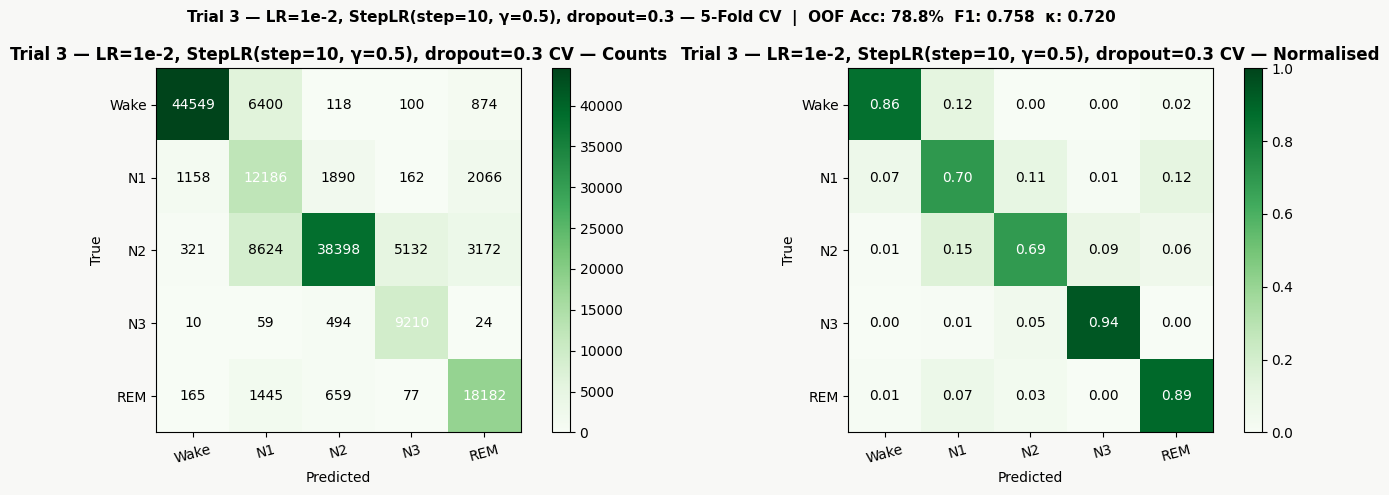

Saved → 04_t3_cv_confusion.png


In [88]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — CV confusion matrix (counts + row-normalised) ──────────────────
cm_cv_t3      = confusion_matrix(_oof_true_t3_arr, _oof_pred_t3_arr,
                                   labels=list(range(N_CLASSES)))
cm_cv_t3_norm = cm_cv_t3.astype(float) / cm_cv_t3.sum(axis=1, keepdims=True)
tnames         = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_cv_t3, cm_cv_t3_norm],
        ['Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 CV — Counts', 'Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 CV — Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_cv_t3_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_cv_t3_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — 5-Fold CV  |  '
    f'OOF Acc: {cv_acc_t3*100:.1f}%  F1: {cv_f1_t3:.3f}  κ: {cv_kappa_t3:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t3_cv_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t3_cv_confusion.png")


In [89]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Retrain on full training set ────────────────────────────────────
# The CV loop above used 80% of the training data per fold.  Here we retrain
# a fresh model on *all* training sequences so the final weights see every
# available labelled epoch before test evaluation.
print(f"{' Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Full retrain ':─^60}")

# Class-weighted sampler over the complete training split
flat_full      = y_seq_tr.flatten()
cc_full        = np.bincount(flat_full, minlength=N_CLASSES).astype(float)
cw_full        = 1.0 / (cc_full + 1e-6)
sw_full        = np.array([cw_full[y_seq_tr[i]].mean()
                            for i in range(len(y_seq_tr))])
sampler_full   = WeightedRandomSampler(
                     torch.tensor(sw_full, dtype=torch.float32),
                     len(sw_full), replacement=True)
cw_norm_full   = cw_full / cw_full.sum() * N_CLASSES
cw_tensor_full = torch.tensor(cw_norm_full, dtype=torch.float32).to(DEVICE)

train_loader_t3 = DataLoader(SeqDataset(X_seq_tr, y_seq_tr),
                                batch_size=32, sampler=sampler_full)
test_loader_t3  = DataLoader(SeqDataset(X_seq_te, y_seq_te),
                                batch_size=32, shuffle=False)

# Fresh model — same architecture and hyper-parameters used in the CV loop
model_t3     = WaveletLSTM(input_size=53, proj=64, hidden=128,
                             num_layers=2, num_classes=5,
                             dropout=0.3).to(DEVICE)
criterion_t3 = nn.CrossEntropyLoss(weight=cw_tensor_full)
optimizer_t3 = torch.optim.Adam(model_t3.parameters(),
                                  lr=1e-2, weight_decay=1e-4)
scheduler_t3 = torch.optim.lr_scheduler.StepLR(optimizer_t3, step_size=10, gamma=0.5)

N_EPOCHS_FULL = 60
PATIENCE_FULL = 10
best_val_t3, wait_t3, best_state_t3 = float('inf'), 0, None
train_losses_t3, val_losses_t3       = [], []

print(f"  Epoch  | Train Loss  | Val Loss")
print(f"  ----------------------------------")

for epoch in range(1, N_EPOCHS_FULL + 1):
    model_t3.train()
    ep_loss, n_b = 0.0, 0
    for X_b, y_b in train_loader_t3:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_t3.zero_grad()
        loss = criterion_t3(model_t3(X_b).reshape(-1, N_CLASSES), y_b.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_t3.parameters(), 1.0)
        optimizer_t3.step()
        ep_loss += loss.item(); n_b += 1

    model_t3.eval()
    vl, nv = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader_t3:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            vl += criterion_t3(model_t3(X_b).reshape(-1, N_CLASSES),
                                 y_b.reshape(-1)).item(); nv += 1

    train_losses_t3.append(ep_loss / n_b)
    val_losses_t3.append(vl / nv)
    scheduler_t3.step()   # StepLR — epoch-based, no val metric needed

    if val_losses_t3[-1] < best_val_t3:
        best_val_t3   = val_losses_t3[-1]; wait_t3 = 0
        best_state_t3 = {k: v.clone() for k, v in model_t3.state_dict().items()}
    else:
        wait_t3 += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:>5}  | {train_losses_t3[-1]:>11.4f} | {val_losses_t3[-1]:>9.4f}")
    if wait_t3 >= PATIENCE_FULL:
        print(f"\n  Early stop at epoch {epoch} (no improvement for {PATIENCE_FULL} epochs)")
        break

model_t3.load_state_dict(best_state_t3)
torch.save(best_state_t3, os.path.join(OUT_DIR, '04_t3_model.pt'))
print(f"\n  Best val loss: {best_val_t3:.4f} — weights saved.")


 Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Full retrain 
  Epoch  | Train Loss  | Val Loss
  ----------------------------------
      1  |      0.6875 |    0.6393
      5  |      0.5022 |    0.5388
     10  |      0.4906 |    0.6033
     15  |      0.4491 |    0.5270
     20  |      0.4340 |    0.5809

  Early stop at epoch 21 (no improvement for 10 epochs)

  Best val loss: 0.5115 — weights saved.


In [90]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Held-out test evaluation + classification report ────────────────
model_t3.eval()
preds_list_t3, trues_list_t3 = [], []
with torch.no_grad():
    for X_b, y_b in test_loader_t3:
        logits = model_t3(X_b.to(DEVICE))
        preds_list_t3.append(logits.argmax(dim=-1).cpu().numpy().flatten())
        trues_list_t3.append(y_b.numpy().flatten())

y_pred_t3 = np.concatenate(preds_list_t3)
y_true_t3 = np.concatenate(trues_list_t3)

test_acc_t3   = accuracy_score(y_true_t3, y_pred_t3)
test_f1_t3    = f1_score(y_true_t3, y_pred_t3, average='macro')
test_kappa_t3 = cohen_kappa_score(y_true_t3, y_pred_t3)

print(f"{' Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Test Results ':═^60}")
print(f"  Accuracy  : {test_acc_t3*100:.2f}%")
print(f"  Macro F1  : {test_f1_t3:.4f}")
print(f"  Cohen's κ : {test_kappa_t3:.4f}  ({kappa_label(test_kappa_t3)})")
print()
tnames = [STAGE_NAMES[s] for s in range(N_CLASSES)]
print(classification_report(y_true_t3, y_pred_t3, target_names=tnames, digits=4))


 Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Test Results 
  Accuracy  : 77.85%
  Macro F1  : 0.7568
  Cohen's κ : 0.7112  (Substantial)

              precision    recall  f1-score   support

        Wake     0.9548    0.8309    0.8885     12122
          N1     0.3940    0.6707    0.4964      4048
          N2     0.9213    0.6875    0.7874     13481
          N3     0.7618    0.9241    0.8351      3242
         REM     0.6928    0.8836    0.7766      5307

    accuracy                         0.7785     38200
   macro avg     0.7449    0.7993    0.7568     38200
weighted avg     0.8308    0.7785    0.7912     38200



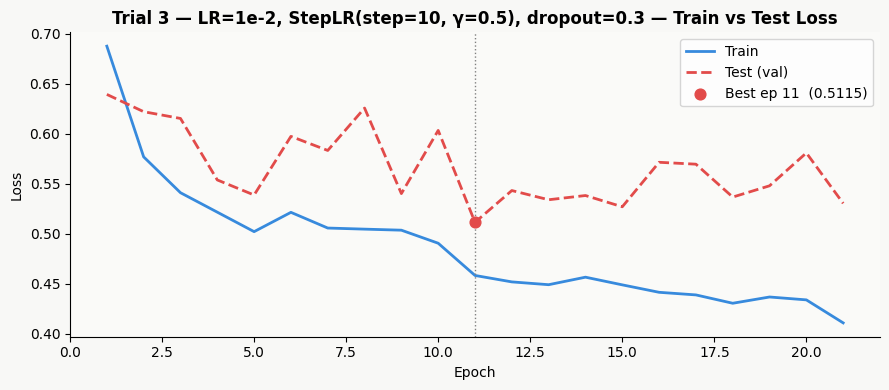

Saved → 04_t3_train_test_loss.png


In [91]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs test loss (full retrain run) ──────────────────────────
ep_range = range(1, len(train_losses_t3) + 1)
best_ep  = int(np.argmin(val_losses_t3))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f8f8f6'); ax.set_facecolor('#fafaf8')

ax.plot(ep_range, train_losses_t3, color='#378ADD', linewidth=2, label='Train')
ax.plot(ep_range, val_losses_t3,   color='#E24B4A', linewidth=2,
        linestyle='--', label='Test (val)')
ax.axvline(best_ep + 1, color='gray', linewidth=1, linestyle=':')
ax.scatter(best_ep + 1, val_losses_t3[best_ep], color='#E24B4A', zorder=5, s=60,
           label=f'Best ep {best_ep+1}  ({val_losses_t3[best_ep]:.4f})')

ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Train vs Test Loss', fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t3_train_test_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t3_train_test_loss.png")


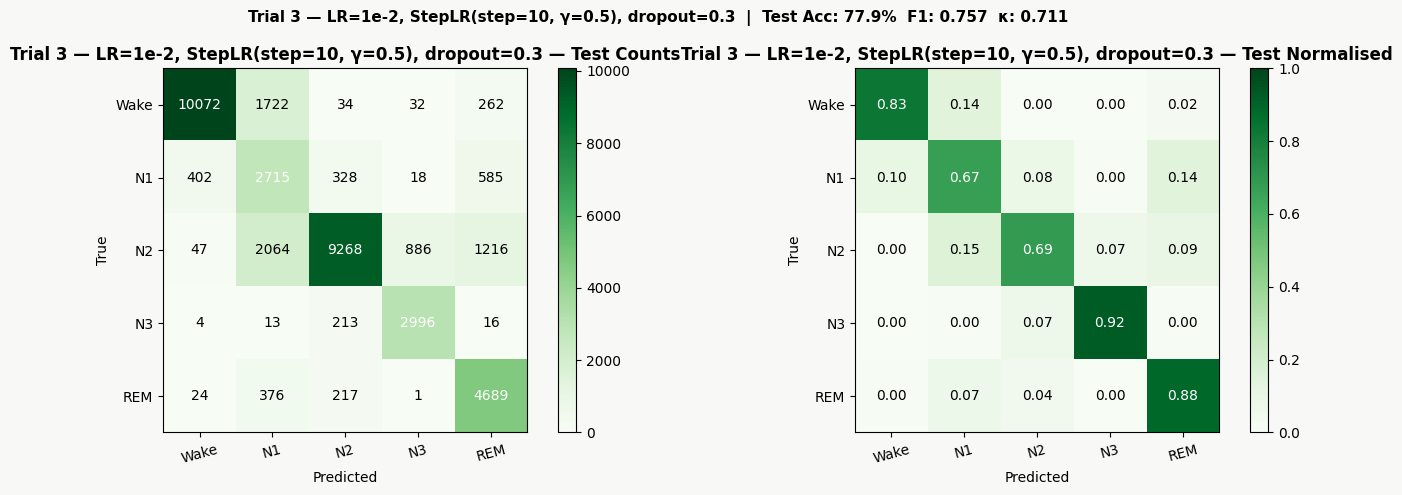

Saved → 04_t3_test_confusion.png


In [92]:
# ── Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Test confusion matrix (counts + row-normalised) ────────────────
cm_t3      = confusion_matrix(y_true_t3, y_pred_t3, labels=list(range(N_CLASSES)))
cm_t3_norm = cm_t3.astype(float) / cm_t3.sum(axis=1, keepdims=True)
tnames      = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_t3, cm_t3_norm],
        ['Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Test Counts', 'Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3 — Test Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_t3_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_t3_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Trial 3 — LR=1e-2, StepLR(step=10, γ=0.5), dropout=0.3  |  '
    f'Test Acc: {test_acc_t3*100:.1f}%  F1: {test_f1_t3:.3f}  κ: {test_kappa_t3:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t3_test_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t3_test_confusion.png")


### Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3

In [94]:
# ── Section 2 | Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — 5-Fold Stratified Cross-Validation ──────────────────
# Fresh storage for this trial; all variables are prefixed 't4_' to avoid
# collisions with other trials running in the same kernel session.

N_FOLDS_CV  = 5
N_EPOCHS_CV = 50
LR_CV       = 1e-3
PATIENCE_CV = 10
SEQ_LEN     = 25   # 25-epoch context window (unchanged throughout)

cv_t4_fold_accs,   cv_t4_fold_f1s,  cv_t4_fold_kappas  = [], [], []
cv_t4_fold_tloss,  cv_t4_fold_vloss                      = [], []
_oof_pred_t4,      _oof_true_t4                          = [], []

# Use the middle epoch of each sequence for stratification
y_mid_t4 = y_seq_tr[:, SEQ_LEN // 2]
skf_t4   = StratifiedKFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=42)

print(f"────────────────────────────────────────────────────────────")
print(f"  Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3  —  {N_FOLDS_CV}-Fold CV")
print(f"  LR=1e-3  |  dropout=0.5  |  wd=1e-3  |  epochs≤50")
print(f"────────────────────────────────────────────────────────────")
print(f"  {'{}'.format('Fold'):>5} | {'{}'.format('Acc'):>7} | "
      f"{'{}'.format('Macro F1'):>9} | {'{}'.format(chr(954)):>7}")
print(f"  {'-'*38}")

for fold, (tr_idx, val_idx) in enumerate(skf_t4.split(X_seq_tr, y_mid_t4)):

    # ── Fold data ─────────────────────────────────────────────────────────────
    X_tr_f,  X_val_f = X_seq_tr[tr_idx],  X_seq_tr[val_idx]
    y_tr_f,  y_val_f = y_seq_tr[tr_idx], y_seq_tr[val_idx]

    # Inverse-frequency class weights + weighted random sampler
    flat_f      = y_tr_f.flatten()
    cc_f        = np.bincount(flat_f, minlength=N_CLASSES).astype(float)
    cw_f        = 1.0 / (cc_f + 1e-6)
    sw_f        = np.array([cw_f[y_tr_f[i]].mean() for i in range(len(y_tr_f))])
    sampler_f   = WeightedRandomSampler(
                      torch.tensor(sw_f, dtype=torch.float32),
                      len(sw_f), replacement=True)
    cw_norm_f   = cw_f / cw_f.sum() * N_CLASSES
    cw_tensor_f = torch.tensor(cw_norm_f, dtype=torch.float32).to(DEVICE)

    loader_tr_f  = DataLoader(SeqDataset(X_tr_f,  y_tr_f),
                               batch_size=32, sampler=sampler_f)
    loader_val_f = DataLoader(SeqDataset(X_val_f, y_val_f),
                               batch_size=32, shuffle=False)

    # ── Fresh model + optimiser for this fold ─────────────────────────────────
    mdl_f  = WaveletLSTM(input_size=53, proj=64, hidden=128,
                          num_layers=2, num_classes=5, dropout=0.5).to(DEVICE)
    crit_f = nn.CrossEntropyLoss(weight=cw_tensor_f)
    opt_f  = torch.optim.Adam(mdl_f.parameters(), lr=LR_CV, weight_decay=1e-3)
    sched_f = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_f, mode="min", factor=0.5, patience=5)

    best_val_f, wait_f, best_st_f = float('inf'), 0, None
    tl_hist_f, vl_hist_f = [], []   # per-epoch loss history for this fold

    # ── Training loop ──────────────────────────────────────────────────────────
    for epoch in range(1, N_EPOCHS_CV + 1):
        mdl_f.train()
        ep_loss, n_b = 0.0, 0
        for X_b, y_b in loader_tr_f:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_f.zero_grad()
            out  = mdl_f(X_b).reshape(-1, N_CLASSES)
            loss = crit_f(out, y_b.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(mdl_f.parameters(), 1.0)
            opt_f.step()
            ep_loss += loss.item(); n_b += 1

        mdl_f.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in loader_val_f:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vl += crit_f(mdl_f(X_b).reshape(-1, N_CLASSES),
                             y_b.reshape(-1)).item(); nv += 1

        tl_hist_f.append(ep_loss / n_b)
        vl_hist_f.append(vl / nv)
        sched_f.step(vl_hist_f[-1])   # ReduceLROnPlateau monitors val loss

        if vl_hist_f[-1] < best_val_f:
            best_val_f = vl_hist_f[-1]; wait_f = 0
            best_st_f  = {k: v.clone() for k, v in mdl_f.state_dict().items()}
        else:
            wait_f += 1
        if wait_f >= PATIENCE_CV:
            break

    # ── Store per-fold loss curves (after all epochs) ─────────────────────────
    cv_t4_fold_tloss.append(tl_hist_f)
    cv_t4_fold_vloss.append(vl_hist_f)

    # ── Evaluate on the held-out fold ──────────────────────────────────────────
    mdl_f.load_state_dict(best_st_f)
    mdl_f.eval()
    preds_f, trues_f = [], []
    with torch.no_grad():
        for X_b, y_b in loader_val_f:
            p = mdl_f(X_b.to(DEVICE)).argmax(dim=-1)
            preds_f.append(p.cpu().numpy().flatten())
            trues_f.append(y_b.numpy().flatten())
    preds_f = np.concatenate(preds_f)
    trues_f = np.concatenate(trues_f)

    acc_f   = accuracy_score(trues_f, preds_f)
    f1_f    = f1_score(trues_f, preds_f, average='macro')
    kappa_f = cohen_kappa_score(trues_f, preds_f)

    cv_t4_fold_accs.append(acc_f);   cv_t4_fold_f1s.append(f1_f)
    cv_t4_fold_kappas.append(kappa_f)
    _oof_pred_t4.extend(preds_f.tolist())
    _oof_true_t4.extend(trues_f.tolist())

    print(f"  {fold+1:>5} | {acc_f*100:>6.2f}% | {f1_f:>9.4f} | {kappa_f:>7.4f}")

print(f"  {'-'*38}")
print(f"  Mean  | {np.mean(cv_t4_fold_accs)*100:>6.2f}% | "
      f"{np.mean(cv_t4_fold_f1s):>9.4f} | {np.mean(cv_t4_fold_kappas):>7.4f}")
print(f"  ±Std  | {np.std(cv_t4_fold_accs)*100:>6.2f}%   | "
      f"{np.std(cv_t4_fold_f1s):>9.4f} | {np.std(cv_t4_fold_kappas):>7.4f}")

# Aggregate OOF arrays for the CV-level confusion matrix and classification report
_oof_pred_t4_arr = np.array(_oof_pred_t4, dtype=np.int64)
_oof_true_t4_arr = np.array(_oof_true_t4, dtype=np.int64)


────────────────────────────────────────────────────────────
  Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3  —  5-Fold CV
  LR=1e-3  |  dropout=0.5  |  wd=1e-3  |  epochs≤50
────────────────────────────────────────────────────────────
   Fold |     Acc |  Macro F1 |       κ
  --------------------------------------
      1 |  76.46% |    0.7392 |  0.6911
      2 |  78.07% |    0.7500 |  0.7111
      3 |  78.84% |    0.7452 |  0.7172
      4 |  77.74% |    0.7459 |  0.7073
      5 |  77.26% |    0.7410 |  0.7006
  --------------------------------------
  Mean  |  77.67% |    0.7443 |  0.7055
  ±Std  |   0.80%   |    0.0038 |  0.0090


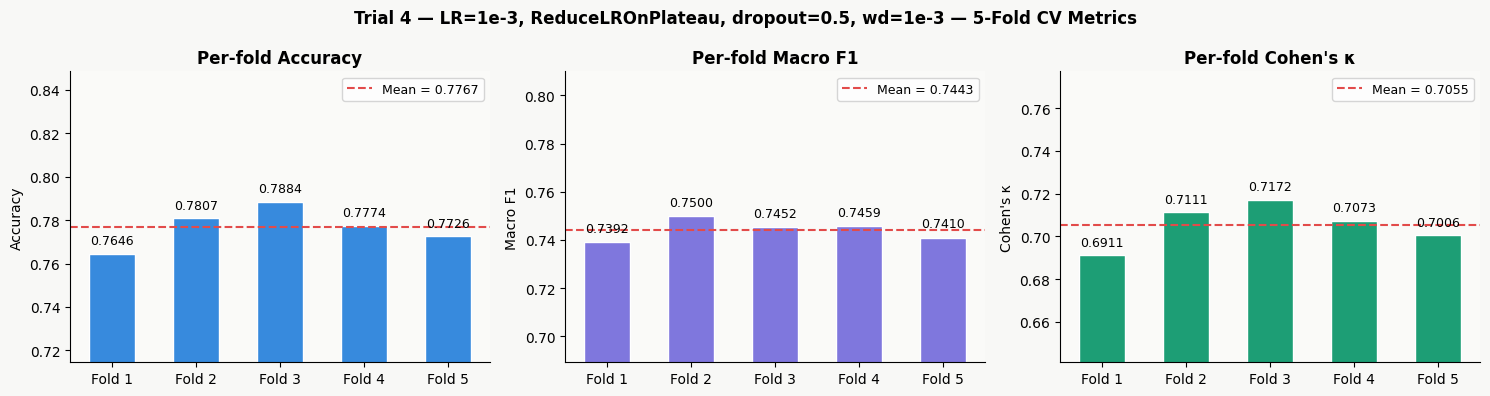

Saved → 04_t4_cv_fold_metrics.png


In [95]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Per-fold bar charts: Accuracy, Macro F1, Cohen's κ ─────────────
fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS_CV)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#f8f8f6')

for ax, (vals, metric_name, color) in zip(axes, [
    (cv_t4_fold_accs,   'Accuracy',   '#378ADD'),
    (cv_t4_fold_f1s,    'Macro F1',   '#7F77DD'),
    (cv_t4_fold_kappas, "Cohen's κ",  '#1D9E75'),
]):
    ax.set_facecolor('#fafaf8')
    bars   = ax.bar(fold_labels, vals, color=color, edgecolor='white', width=0.55)
    mean_v = np.mean(vals)
    ax.axhline(mean_v, color='#E24B4A', linewidth=1.5,
               linestyle='--', label=f'Mean = {mean_v:.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Per-fold {metric_name}', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.06))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — 5-Fold CV Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t4_cv_fold_metrics.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t4_cv_fold_metrics.png")


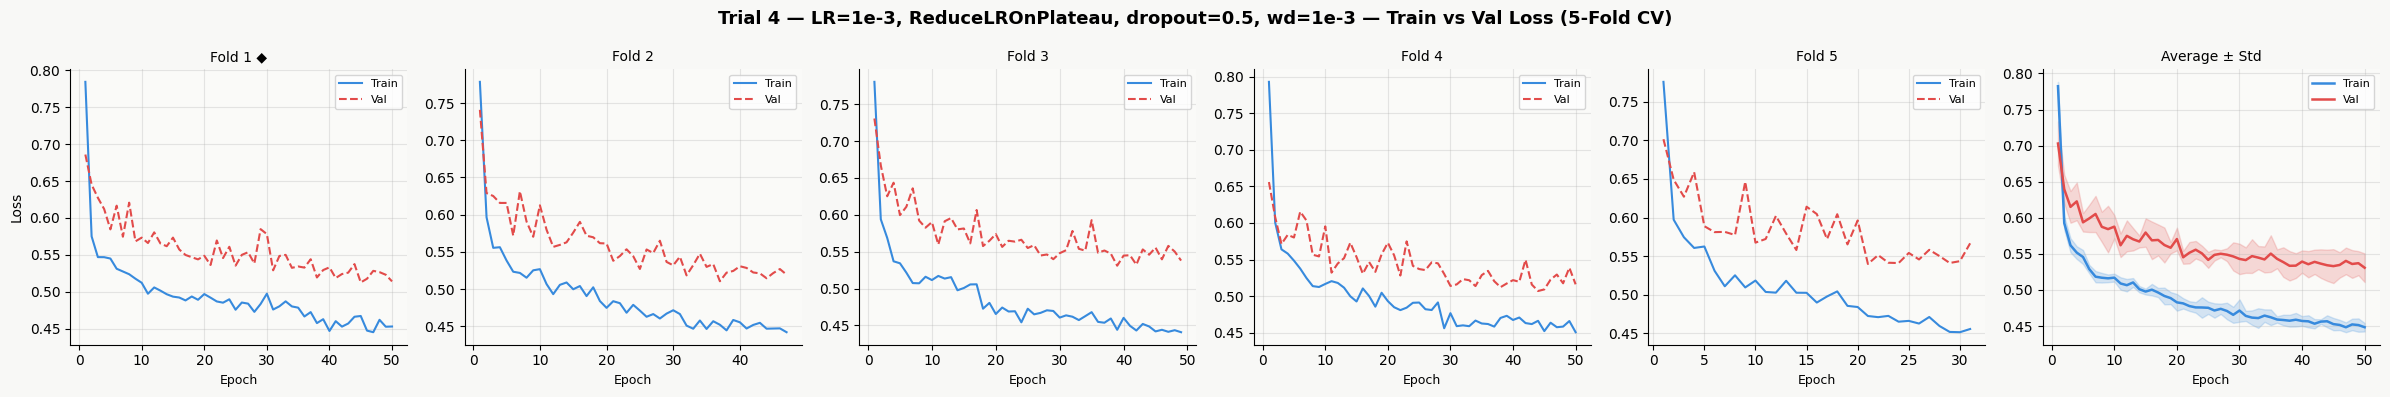

Saved → 04_t4_cv_fold_loss.png


In [96]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Train vs Val loss curves (5 folds + mean±std panel) ────────────
def _pad(lst, length):
    """Right-pad a list with its last value so curves align to the same length."""
    return lst + [lst[-1]] * (length - len(lst))

best_fold_t4 = int(np.argmin([h[-1] for h in cv_t4_fold_vloss])) + 1
n_panels      = N_FOLDS_CV + 1   # one per fold + one average panel

fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
fig.patch.set_facecolor('#f8f8f6')

for i, ax in enumerate(axes[:N_FOLDS_CV]):
    marker = ' ◆' if (i + 1) == best_fold_t4 else ''
    ep_range = range(1, len(cv_t4_fold_tloss[i]) + 1)
    ax.plot(ep_range, cv_t4_fold_tloss[i], color='#378ADD', linewidth=1.5, label='Train')
    ax.plot(ep_range, cv_t4_fold_vloss[i], color='#E24B4A', linewidth=1.5,
            linestyle='--', label='Val')
    ax.set_title(f'Fold {i+1}{marker}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_facecolor('#fafaf8')
    ax.spines[['top', 'right']].set_visible(False)

# Average ± std panel
ax_avg    = axes[-1]
max_ep    = max(len(h) for h in cv_t4_fold_tloss)
train_mat = np.array([_pad(h, max_ep) for h in cv_t4_fold_tloss])
val_mat   = np.array([_pad(h, max_ep) for h in cv_t4_fold_vloss])
ep_arr    = np.arange(1, max_ep + 1)

for mat, color, lbl in [(train_mat, '#378ADD', 'Train'), (val_mat, '#E24B4A', 'Val')]:
    m, s = mat.mean(axis=0), mat.std(axis=0)
    ax_avg.plot(ep_arr, m, color=color, linewidth=1.8, label=lbl)
    ax_avg.fill_between(ep_arr, m - s, m + s, alpha=0.2, color=color)

ax_avg.set_title('Average ± Std', fontsize=10)
ax_avg.set_xlabel('Epoch', fontsize=9)
ax_avg.legend(fontsize=8); ax_avg.grid(alpha=0.3); ax_avg.set_facecolor('#fafaf8')
ax_avg.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Train vs Val Loss (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t4_cv_fold_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t4_cv_fold_loss.png")


In [97]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — CV summary + OOF classification report ─────────────────────────
cv_acc_t4   = accuracy_score(_oof_true_t4_arr, _oof_pred_t4_arr)
cv_f1_t4    = f1_score(_oof_true_t4_arr, _oof_pred_t4_arr, average='macro')
cv_kappa_t4 = cohen_kappa_score(_oof_true_t4_arr, _oof_pred_t4_arr)

print(f"{' Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — CV Summary ':═^65}")
print(f"  OOF Accuracy  : {cv_acc_t4*100:.2f}%")
print(f"  OOF Macro F1  : {cv_f1_t4:.4f}")
print(f"  OOF Cohen's κ : {cv_kappa_t4:.4f}  ({kappa_label(cv_kappa_t4)})")
print(f"  Per-fold Acc  : {np.mean(cv_t4_fold_accs)*100:.2f}%"
      f" ± {np.std(cv_t4_fold_accs)*100:.2f}%")
print(f"  Per-fold F1   : {np.mean(cv_t4_fold_f1s):.4f}"
      f" ± {np.std(cv_t4_fold_f1s):.4f}")
print(f"  Per-fold κ    : {np.mean(cv_t4_fold_kappas):.4f}"
      f" ± {np.std(cv_t4_fold_kappas):.4f}")
print()
tnames = [STAGE_NAMES[s] for s in range(5)]
print(classification_report(_oof_true_t4_arr, _oof_pred_t4_arr,
                             target_names=tnames, digits=4))


 Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — CV Summary 
  OOF Accuracy  : 77.67%
  OOF Macro F1  : 0.7444
  OOF Cohen's κ : 0.7055  (Substantial)
  Per-fold Acc  : 77.67% ± 0.80%
  Per-fold F1   : 0.7443 ± 0.0038
  Per-fold κ    : 0.7055 ± 0.0090

              precision    recall  f1-score   support

        Wake     0.9664    0.8376    0.8974     52041
          N1     0.4020    0.6657    0.5013     17462
          N2     0.9115    0.6936    0.7877     55647
          N3     0.6097    0.9339    0.7377      9797
         REM     0.7388    0.8674    0.7979     20528

    accuracy                         0.7767    155475
   macro avg     0.7257    0.7996    0.7444    155475
weighted avg     0.8308    0.7767    0.7905    155475



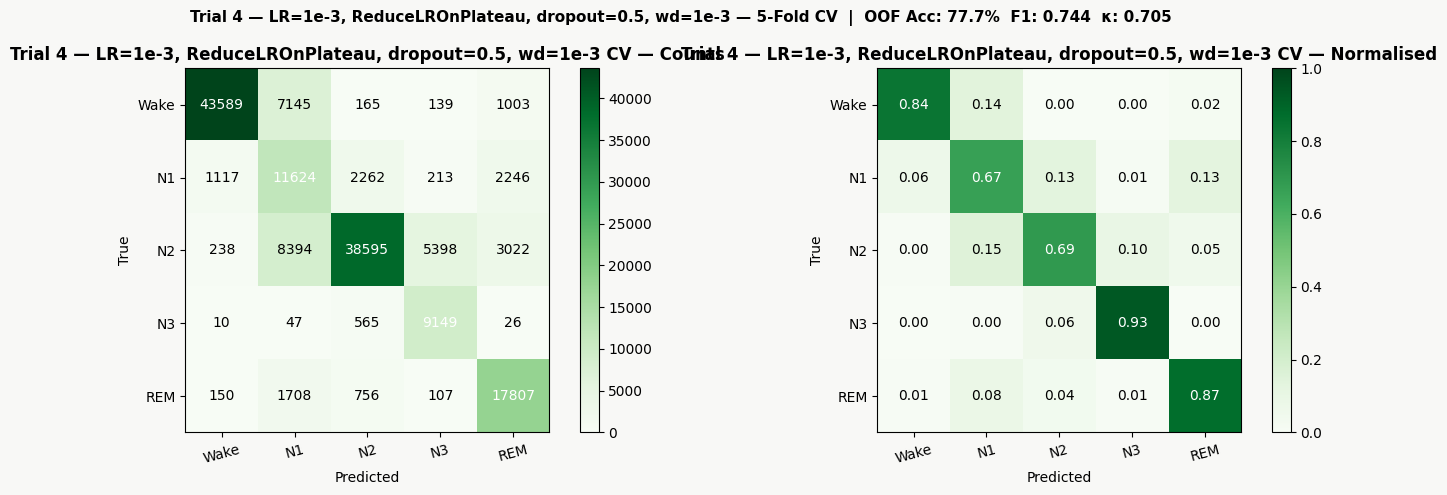

Saved → 04_t4_cv_confusion.png


In [98]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — CV confusion matrix (counts + row-normalised) ──────────────────
cm_cv_t4      = confusion_matrix(_oof_true_t4_arr, _oof_pred_t4_arr,
                                   labels=list(range(N_CLASSES)))
cm_cv_t4_norm = cm_cv_t4.astype(float) / cm_cv_t4.sum(axis=1, keepdims=True)
tnames         = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_cv_t4, cm_cv_t4_norm],
        ['Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 CV — Counts', 'Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 CV — Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_cv_t4_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_cv_t4_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — 5-Fold CV  |  '
    f'OOF Acc: {cv_acc_t4*100:.1f}%  F1: {cv_f1_t4:.3f}  κ: {cv_kappa_t4:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t4_cv_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t4_cv_confusion.png")


In [99]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Retrain on full training set ────────────────────────────────────
# The CV loop above used 80% of the training data per fold.  Here we retrain
# a fresh model on *all* training sequences so the final weights see every
# available labelled epoch before test evaluation.
print(f"{' Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Full retrain ':─^60}")

# Class-weighted sampler over the complete training split
flat_full      = y_seq_tr.flatten()
cc_full        = np.bincount(flat_full, minlength=N_CLASSES).astype(float)
cw_full        = 1.0 / (cc_full + 1e-6)
sw_full        = np.array([cw_full[y_seq_tr[i]].mean()
                            for i in range(len(y_seq_tr))])
sampler_full   = WeightedRandomSampler(
                     torch.tensor(sw_full, dtype=torch.float32),
                     len(sw_full), replacement=True)
cw_norm_full   = cw_full / cw_full.sum() * N_CLASSES
cw_tensor_full = torch.tensor(cw_norm_full, dtype=torch.float32).to(DEVICE)

train_loader_t4 = DataLoader(SeqDataset(X_seq_tr, y_seq_tr),
                                batch_size=32, sampler=sampler_full)
test_loader_t4  = DataLoader(SeqDataset(X_seq_te, y_seq_te),
                                batch_size=32, shuffle=False)

# Fresh model — same architecture and hyper-parameters used in the CV loop
model_t4     = WaveletLSTM(input_size=53, proj=64, hidden=128,
                             num_layers=2, num_classes=5,
                             dropout=0.5).to(DEVICE)
criterion_t4 = nn.CrossEntropyLoss(weight=cw_tensor_full)
optimizer_t4 = torch.optim.Adam(model_t4.parameters(),
                                  lr=1e-3, weight_decay=1e-3)
scheduler_t4 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_t4, mode="min", factor=0.5, patience=5)

N_EPOCHS_FULL = 50
PATIENCE_FULL = 10
best_val_t4, wait_t4, best_state_t4 = float('inf'), 0, None
train_losses_t4, val_losses_t4       = [], []

print(f"  Epoch  | Train Loss  | Val Loss")
print(f"  ----------------------------------")

for epoch in range(1, N_EPOCHS_FULL + 1):
    model_t4.train()
    ep_loss, n_b = 0.0, 0
    for X_b, y_b in train_loader_t4:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_t4.zero_grad()
        loss = criterion_t4(model_t4(X_b).reshape(-1, N_CLASSES), y_b.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_t4.parameters(), 1.0)
        optimizer_t4.step()
        ep_loss += loss.item(); n_b += 1

    model_t4.eval()
    vl, nv = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader_t4:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            vl += criterion_t4(model_t4(X_b).reshape(-1, N_CLASSES),
                                 y_b.reshape(-1)).item(); nv += 1

    train_losses_t4.append(ep_loss / n_b)
    val_losses_t4.append(vl / nv)
    scheduler_t4.step(val_losses_t4[-1])   # ReduceLROnPlateau monitors val loss

    if val_losses_t4[-1] < best_val_t4:
        best_val_t4   = val_losses_t4[-1]; wait_t4 = 0
        best_state_t4 = {k: v.clone() for k, v in model_t4.state_dict().items()}
    else:
        wait_t4 += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:>5}  | {train_losses_t4[-1]:>11.4f} | {val_losses_t4[-1]:>9.4f}")
    if wait_t4 >= PATIENCE_FULL:
        print(f"\n  Early stop at epoch {epoch} (no improvement for {PATIENCE_FULL} epochs)")
        break

model_t4.load_state_dict(best_state_t4)
torch.save(best_state_t4, os.path.join(OUT_DIR, '04_t4_model.pt'))
print(f"\n  Best val loss: {best_val_t4:.4f} — weights saved.")


 Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Full retrain 
  Epoch  | Train Loss  | Val Loss
  ----------------------------------
      1  |      0.7398 |    0.6498
      5  |      0.5421 |    0.5795
     10  |      0.5015 |    0.6025
     15  |      0.4786 |    0.5543
     20  |      0.4702 |    0.5278
     25  |      0.4698 |    0.5405
     30  |      0.4500 |    0.5347
     35  |      0.4574 |    0.5349
     40  |      0.4587 |    0.5376
     45  |      0.4467 |    0.5405

  Early stop at epoch 46 (no improvement for 10 epochs)

  Best val loss: 0.5229 — weights saved.


In [100]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Held-out test evaluation + classification report ────────────────
model_t4.eval()
preds_list_t4, trues_list_t4 = [], []
with torch.no_grad():
    for X_b, y_b in test_loader_t4:
        logits = model_t4(X_b.to(DEVICE))
        preds_list_t4.append(logits.argmax(dim=-1).cpu().numpy().flatten())
        trues_list_t4.append(y_b.numpy().flatten())

y_pred_t4 = np.concatenate(preds_list_t4)
y_true_t4 = np.concatenate(trues_list_t4)

test_acc_t4   = accuracy_score(y_true_t4, y_pred_t4)
test_f1_t4    = f1_score(y_true_t4, y_pred_t4, average='macro')
test_kappa_t4 = cohen_kappa_score(y_true_t4, y_pred_t4)

print(f"{' Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Test Results ':═^60}")
print(f"  Accuracy  : {test_acc_t4*100:.2f}%")
print(f"  Macro F1  : {test_f1_t4:.4f}")
print(f"  Cohen's κ : {test_kappa_t4:.4f}  ({kappa_label(test_kappa_t4)})")
print()
tnames = [STAGE_NAMES[s] for s in range(N_CLASSES)]
print(classification_report(y_true_t4, y_pred_t4, target_names=tnames, digits=4))


 Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Test Results 
  Accuracy  : 78.41%
  Macro F1  : 0.7603
  Cohen's κ : 0.7175  (Substantial)

              precision    recall  f1-score   support

        Wake     0.9567    0.8394    0.8942     12122
          N1     0.3928    0.6586    0.4921      4048
          N2     0.9125    0.7053    0.7956     13481
          N3     0.7699    0.9022    0.8308      3242
         REM     0.7133    0.8815    0.7885      5307

    accuracy                         0.7841     38200
   macro avg     0.7490    0.7974    0.7603     38200
weighted avg     0.8317    0.7841    0.7967     38200



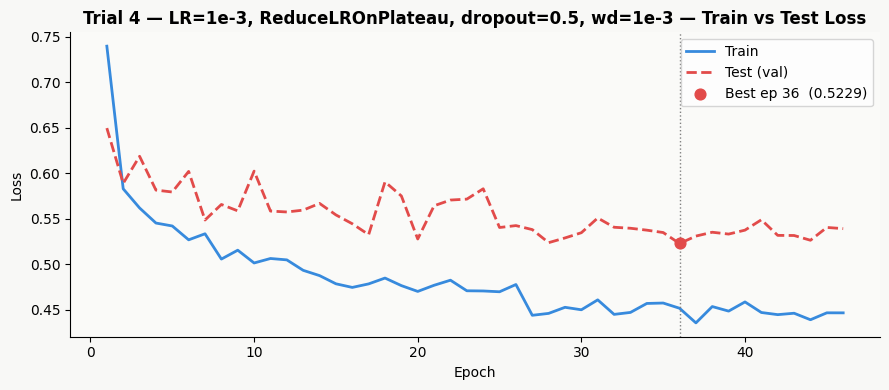

Saved → 04_t4_train_test_loss.png


In [101]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Train vs test loss (full retrain run) ──────────────────────────
ep_range = range(1, len(train_losses_t4) + 1)
best_ep  = int(np.argmin(val_losses_t4))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f8f8f6'); ax.set_facecolor('#fafaf8')

ax.plot(ep_range, train_losses_t4, color='#378ADD', linewidth=2, label='Train')
ax.plot(ep_range, val_losses_t4,   color='#E24B4A', linewidth=2,
        linestyle='--', label='Test (val)')
ax.axvline(best_ep + 1, color='gray', linewidth=1, linestyle=':')
ax.scatter(best_ep + 1, val_losses_t4[best_ep], color='#E24B4A', zorder=5, s=60,
           label=f'Best ep {best_ep+1}  ({val_losses_t4[best_ep]:.4f})')

ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Train vs Test Loss', fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t4_train_test_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t4_train_test_loss.png")


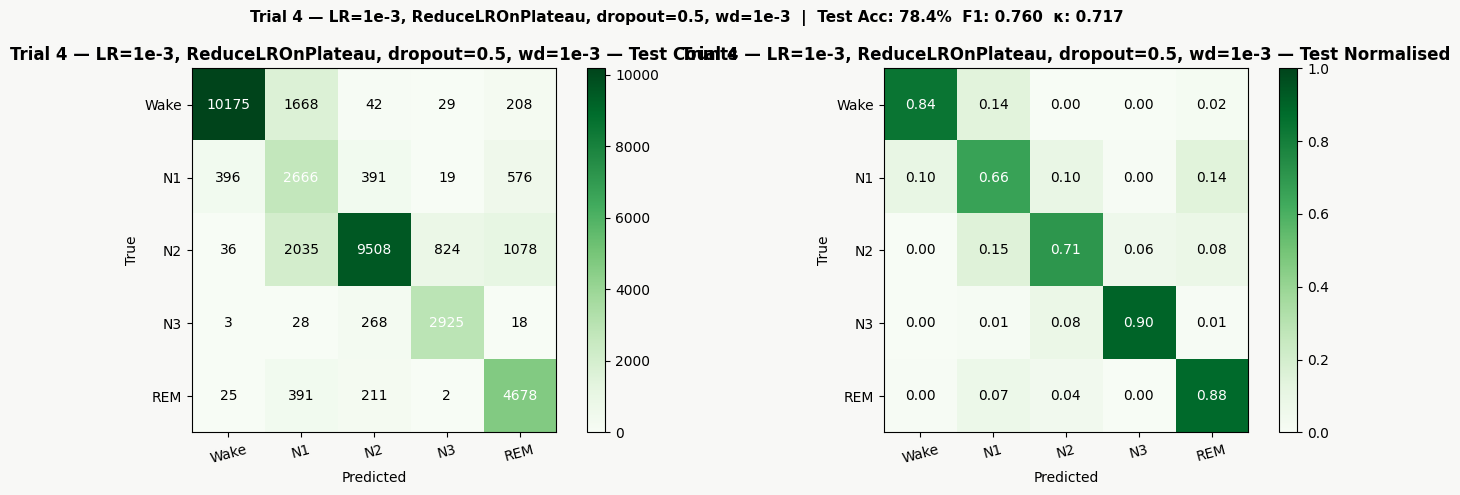

Saved → 04_t4_test_confusion.png


In [102]:
# ── Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Test confusion matrix (counts + row-normalised) ────────────────
cm_t4      = confusion_matrix(y_true_t4, y_pred_t4, labels=list(range(N_CLASSES)))
cm_t4_norm = cm_t4.astype(float) / cm_t4.sum(axis=1, keepdims=True)
tnames      = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_t4, cm_t4_norm],
        ['Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Test Counts', 'Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3 — Test Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_t4_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_t4_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Trial 4 — LR=1e-3, ReduceLROnPlateau, dropout=0.5, wd=1e-3  |  '
    f'Test Acc: {test_acc_t4*100:.1f}%  F1: {test_f1_t4:.3f}  κ: {test_kappa_t4:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_t4_test_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 04_t4_test_confusion.png")


## Section 3: Wavelet+BiLSTM: CWT features only (ablation)

* Rationale: isolate whether CWT sub-band statistics alone carry enough
discriminative information for temporal modelling, without time-domain
(Hjorth, ZCR, RMS) or Welch relative power features.
* Feature layout in X_seq_tr (axis=2):
  * indices  0–39 : CWT sub-band statistics (5 bands × 8 stats)
  * indices 40–47 : time-domain descriptors
  * indices 48–52 : Welch relative spectral power
* We reuse the existing X_seq_tr / X_seq_te and slice axis=2.

In [103]:
N_CWT = 40

X_seq_tr_cwt = X_seq_tr[:, :, :N_CWT]   # (n_seq, 25, 40)
X_seq_te_cwt = X_seq_te[:, :, :N_CWT]   # (n_seq, 25, 40)

print(f"CWT-only train sequences : {X_seq_tr_cwt.shape}")
print(f"CWT-only test  sequences : {X_seq_te_cwt.shape}")

CWT-only train sequences : (6219, 25, 40)
CWT-only test  sequences : (1528, 25, 40)


### Trial 1 - CWT-40, CrossEntropyLoss, ReduceLROnPlateau

In [105]:
# Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — 5-Fold Stratified Cross-Validation ──────────────────
# Fresh storage for this trial; all variables are prefixed 's3ce_' to avoid
# collisions with other trials running in the same kernel session.

N_FOLDS_CV  = 5
N_EPOCHS_CV = 50
LR_CV       = 1e-3
PATIENCE_CV = 10
SEQ_LEN     = 25   # 25-epoch context window (unchanged throughout)

cv_s3ce_fold_accs,   cv_s3ce_fold_f1s,  cv_s3ce_fold_kappas  = [], [], []
cv_s3ce_fold_tloss,  cv_s3ce_fold_vloss                      = [], []
_oof_pred_s3ce,      _oof_true_s3ce                          = [], []

# Use the middle epoch of each sequence for stratification
y_mid_s3ce = y_seq_tr[:, SEQ_LEN // 2]
skf_s3ce   = StratifiedKFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=42)

print(f"────────────────────────────────────────────────────────────")
print(f"  Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau  —  {N_FOLDS_CV}-Fold CV")
print(f"  LR=1e-3  |  dropout=0.5  |  wd=1e-3  |  epochs≤50")
print(f"────────────────────────────────────────────────────────────")
print(f"  {'{}'.format('Fold'):>5} | {'{}'.format('Acc'):>7} | "
      f"{'{}'.format('Macro F1'):>9} | {'{}'.format(chr(954)):>7}")
print(f"  {'-'*38}")

for fold, (tr_idx, val_idx) in enumerate(skf_s3ce.split(X_seq_tr_cwt, y_mid_s3ce)):

    # ── Fold data ─────────────────────────────────────────────────────────────
    X_tr_f,  X_val_f = X_seq_tr_cwt[tr_idx],  X_seq_tr_cwt[val_idx]
    y_tr_f,  y_val_f = y_seq_tr[tr_idx], y_seq_tr[val_idx]

    # Inverse-frequency class weights + weighted random sampler
    flat_f      = y_tr_f.flatten()
    cc_f        = np.bincount(flat_f, minlength=N_CLASSES).astype(float)
    cw_f        = 1.0 / (cc_f + 1e-6)
    sw_f        = np.array([cw_f[y_tr_f[i]].mean() for i in range(len(y_tr_f))])
    sampler_f   = WeightedRandomSampler(
                      torch.tensor(sw_f, dtype=torch.float32),
                      len(sw_f), replacement=True)
    cw_norm_f   = cw_f / cw_f.sum() * N_CLASSES
    cw_tensor_f = torch.tensor(cw_norm_f, dtype=torch.float32).to(DEVICE)

    loader_tr_f  = DataLoader(SeqDataset(X_tr_f,  y_tr_f),
                               batch_size=32, sampler=sampler_f)
    loader_val_f = DataLoader(SeqDataset(X_val_f, y_val_f),
                               batch_size=32, shuffle=False)

    # ── Fresh model + optimiser for this fold ─────────────────────────────────
    mdl_f  = WaveletLSTM(input_size=40, proj=64, hidden=128,
                          num_layers=2, num_classes=5, dropout=0.5).to(DEVICE)
    crit_f = nn.CrossEntropyLoss(weight=cw_tensor_f)
    opt_f  = torch.optim.Adam(mdl_f.parameters(), lr=LR_CV, weight_decay=1e-3)
    sched_f = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_f, mode="min", factor=0.5, patience=5)

    best_val_f, wait_f, best_st_f = float('inf'), 0, None
    tl_hist_f, vl_hist_f = [], []   # per-epoch loss history for this fold

    # ── Training loop ──────────────────────────────────────────────────────────
    for epoch in range(1, N_EPOCHS_CV + 1):
        mdl_f.train()
        ep_loss, n_b = 0.0, 0
        for X_b, y_b in loader_tr_f:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_f.zero_grad()
            out  = mdl_f(X_b).reshape(-1, N_CLASSES)
            loss = crit_f(out, y_b.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(mdl_f.parameters(), 1.0)
            opt_f.step()
            ep_loss += loss.item(); n_b += 1

        mdl_f.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in loader_val_f:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vl += crit_f(mdl_f(X_b).reshape(-1, N_CLASSES),
                             y_b.reshape(-1)).item(); nv += 1

        tl_hist_f.append(ep_loss / n_b)
        vl_hist_f.append(vl / nv)
        sched_f.step(vl_hist_f[-1])   # ReduceLROnPlateau monitors val loss

        if vl_hist_f[-1] < best_val_f:
            best_val_f = vl_hist_f[-1]; wait_f = 0
            best_st_f  = {k: v.clone() for k, v in mdl_f.state_dict().items()}
        else:
            wait_f += 1
        if wait_f >= PATIENCE_CV:
            break

    # ── Store per-fold loss curves (after all epochs) ─────────────────────────
    cv_s3ce_fold_tloss.append(tl_hist_f)
    cv_s3ce_fold_vloss.append(vl_hist_f)

    # ── Evaluate on the held-out fold ──────────────────────────────────────────
    mdl_f.load_state_dict(best_st_f)
    mdl_f.eval()
    preds_f, trues_f = [], []
    with torch.no_grad():
        for X_b, y_b in loader_val_f:
            p = mdl_f(X_b.to(DEVICE)).argmax(dim=-1)
            preds_f.append(p.cpu().numpy().flatten())
            trues_f.append(y_b.numpy().flatten())
    preds_f = np.concatenate(preds_f)
    trues_f = np.concatenate(trues_f)

    acc_f   = accuracy_score(trues_f, preds_f)
    f1_f    = f1_score(trues_f, preds_f, average='macro')
    kappa_f = cohen_kappa_score(trues_f, preds_f)

    cv_s3ce_fold_accs.append(acc_f);   cv_s3ce_fold_f1s.append(f1_f)
    cv_s3ce_fold_kappas.append(kappa_f)
    _oof_pred_s3ce.extend(preds_f.tolist())
    _oof_true_s3ce.extend(trues_f.tolist())

    print(f"  {fold+1:>5} | {acc_f*100:>6.2f}% | {f1_f:>9.4f} | {kappa_f:>7.4f}")

print(f"  {'-'*38}")
print(f"  Mean  | {np.mean(cv_s3ce_fold_accs)*100:>6.2f}% | "
      f"{np.mean(cv_s3ce_fold_f1s):>9.4f} | {np.mean(cv_s3ce_fold_kappas):>7.4f}")
print(f"  ±Std  | {np.std(cv_s3ce_fold_accs)*100:>6.2f}%   | "
      f"{np.std(cv_s3ce_fold_f1s):>9.4f} | {np.std(cv_s3ce_fold_kappas):>7.4f}")

# Aggregate OOF arrays for the CV-level confusion matrix and classification report
_oof_pred_s3ce_arr = np.array(_oof_pred_s3ce, dtype=np.int64)
_oof_true_s3ce_arr = np.array(_oof_true_s3ce, dtype=np.int64)


────────────────────────────────────────────────────────────
  Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau  —  5-Fold CV
  LR=1e-3  |  dropout=0.5  |  wd=1e-3  |  epochs≤50
────────────────────────────────────────────────────────────
   Fold |     Acc |  Macro F1 |       κ
  --------------------------------------
      1 |  76.82% |    0.7318 |  0.6938
      2 |  75.68% |    0.7279 |  0.6813
      3 |  75.06% |    0.7154 |  0.6711
      4 |  75.47% |    0.7293 |  0.6802
      5 |  74.59% |    0.7249 |  0.6689
  --------------------------------------
  Mean  |  75.52% |    0.7259 |  0.6791
  ±Std  |   0.75%   |    0.0057 |  0.0088


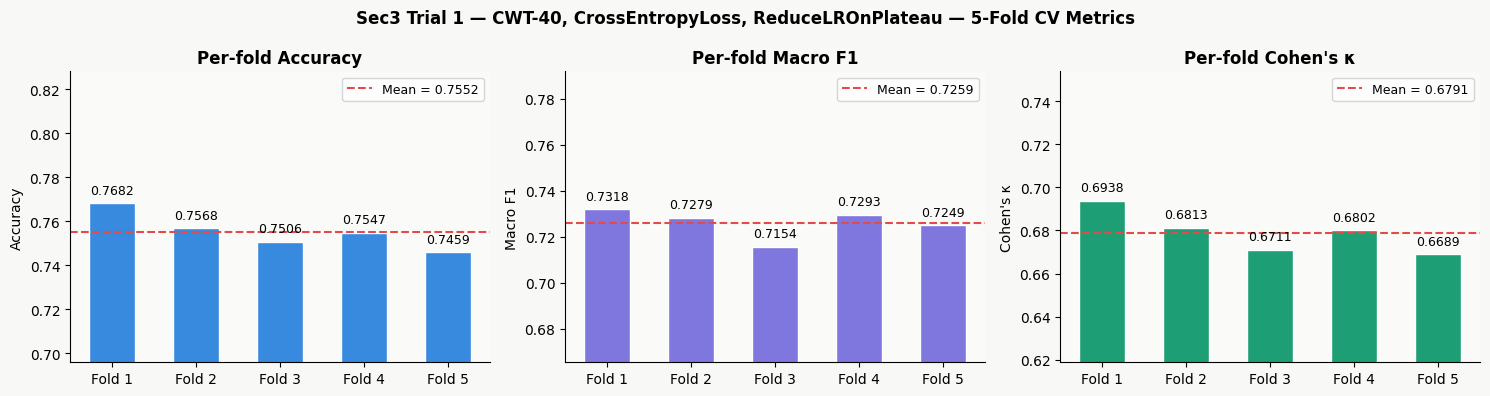

Saved → 05_s3_ce_cv_fold_metrics.png


In [106]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Per-fold bar charts: Accuracy, Macro F1, Cohen's κ ─────────────
fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS_CV)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#f8f8f6')

for ax, (vals, metric_name, color) in zip(axes, [
    (cv_s3ce_fold_accs,   'Accuracy',   '#378ADD'),
    (cv_s3ce_fold_f1s,    'Macro F1',   '#7F77DD'),
    (cv_s3ce_fold_kappas, "Cohen's κ",  '#1D9E75'),
]):
    ax.set_facecolor('#fafaf8')
    bars   = ax.bar(fold_labels, vals, color=color, edgecolor='white', width=0.55)
    mean_v = np.mean(vals)
    ax.axhline(mean_v, color='#E24B4A', linewidth=1.5,
               linestyle='--', label=f'Mean = {mean_v:.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Per-fold {metric_name}', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.06))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — 5-Fold CV Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_ce_cv_fold_metrics.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_ce_cv_fold_metrics.png")


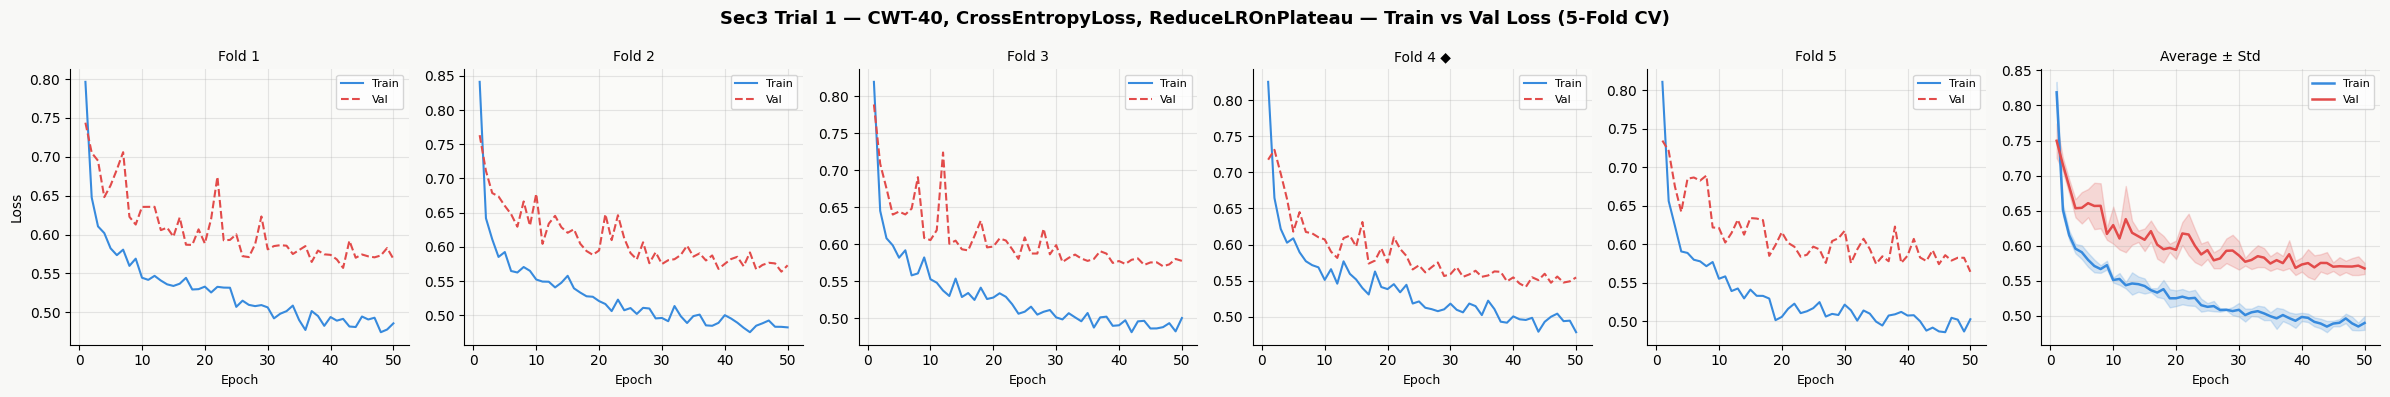

Saved → 05_s3_ce_cv_fold_loss.png


In [107]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Train vs Val loss curves (5 folds + mean±std panel) ────────────
def _pad(lst, length):
    """Right-pad a list with its last value so curves align to the same length."""
    return lst + [lst[-1]] * (length - len(lst))

best_fold_s3ce = int(np.argmin([h[-1] for h in cv_s3ce_fold_vloss])) + 1
n_panels      = N_FOLDS_CV + 1   # one per fold + one average panel

fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
fig.patch.set_facecolor('#f8f8f6')

for i, ax in enumerate(axes[:N_FOLDS_CV]):
    marker = ' ◆' if (i + 1) == best_fold_s3ce else ''
    ep_range = range(1, len(cv_s3ce_fold_tloss[i]) + 1)
    ax.plot(ep_range, cv_s3ce_fold_tloss[i], color='#378ADD', linewidth=1.5, label='Train')
    ax.plot(ep_range, cv_s3ce_fold_vloss[i], color='#E24B4A', linewidth=1.5,
            linestyle='--', label='Val')
    ax.set_title(f'Fold {i+1}{marker}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_facecolor('#fafaf8')
    ax.spines[['top', 'right']].set_visible(False)

# Average ± std panel
ax_avg    = axes[-1]
max_ep    = max(len(h) for h in cv_s3ce_fold_tloss)
train_mat = np.array([_pad(h, max_ep) for h in cv_s3ce_fold_tloss])
val_mat   = np.array([_pad(h, max_ep) for h in cv_s3ce_fold_vloss])
ep_arr    = np.arange(1, max_ep + 1)

for mat, color, lbl in [(train_mat, '#378ADD', 'Train'), (val_mat, '#E24B4A', 'Val')]:
    m, s = mat.mean(axis=0), mat.std(axis=0)
    ax_avg.plot(ep_arr, m, color=color, linewidth=1.8, label=lbl)
    ax_avg.fill_between(ep_arr, m - s, m + s, alpha=0.2, color=color)

ax_avg.set_title('Average ± Std', fontsize=10)
ax_avg.set_xlabel('Epoch', fontsize=9)
ax_avg.legend(fontsize=8); ax_avg.grid(alpha=0.3); ax_avg.set_facecolor('#fafaf8')
ax_avg.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Train vs Val Loss (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_ce_cv_fold_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_ce_cv_fold_loss.png")


In [108]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — CV summary + OOF classification report ─────────────────────────
cv_acc_s3ce   = accuracy_score(_oof_true_s3ce_arr, _oof_pred_s3ce_arr)
cv_f1_s3ce    = f1_score(_oof_true_s3ce_arr, _oof_pred_s3ce_arr, average='macro')
cv_kappa_s3ce = cohen_kappa_score(_oof_true_s3ce_arr, _oof_pred_s3ce_arr)

print(f"{' Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — CV Summary ':═^65}")
print(f"  OOF Accuracy  : {cv_acc_s3ce*100:.2f}%")
print(f"  OOF Macro F1  : {cv_f1_s3ce:.4f}")
print(f"  OOF Cohen's κ : {cv_kappa_s3ce:.4f}  ({kappa_label(cv_kappa_s3ce)})")
print(f"  Per-fold Acc  : {np.mean(cv_s3ce_fold_accs)*100:.2f}%"
      f" ± {np.std(cv_s3ce_fold_accs)*100:.2f}%")
print(f"  Per-fold F1   : {np.mean(cv_s3ce_fold_f1s):.4f}"
      f" ± {np.std(cv_s3ce_fold_f1s):.4f}")
print(f"  Per-fold κ    : {np.mean(cv_s3ce_fold_kappas):.4f}"
      f" ± {np.std(cv_s3ce_fold_kappas):.4f}")
print()
tnames = [STAGE_NAMES[s] for s in range(5)]
print(classification_report(_oof_true_s3ce_arr, _oof_pred_s3ce_arr,
                             target_names=tnames, digits=4))


 Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — CV Summary 
  OOF Accuracy  : 75.52%
  OOF Macro F1  : 0.7260
  OOF Cohen's κ : 0.6791  (Substantial)
  Per-fold Acc  : 75.52% ± 0.75%
  Per-fold F1   : 0.7259 ± 0.0057
  Per-fold κ    : 0.6791 ± 0.0088

              precision    recall  f1-score   support

        Wake     0.9632    0.8276    0.8902     52041
          N1     0.3726    0.6619    0.4768     17462
          N2     0.9102    0.6492    0.7578     55647
          N3     0.6046    0.9331    0.7338      9797
         REM     0.7032    0.8540    0.7713     20528

    accuracy                         0.7552    155475
   macro avg     0.7108    0.7851    0.7260    155475
weighted avg     0.8210    0.7552    0.7708    155475



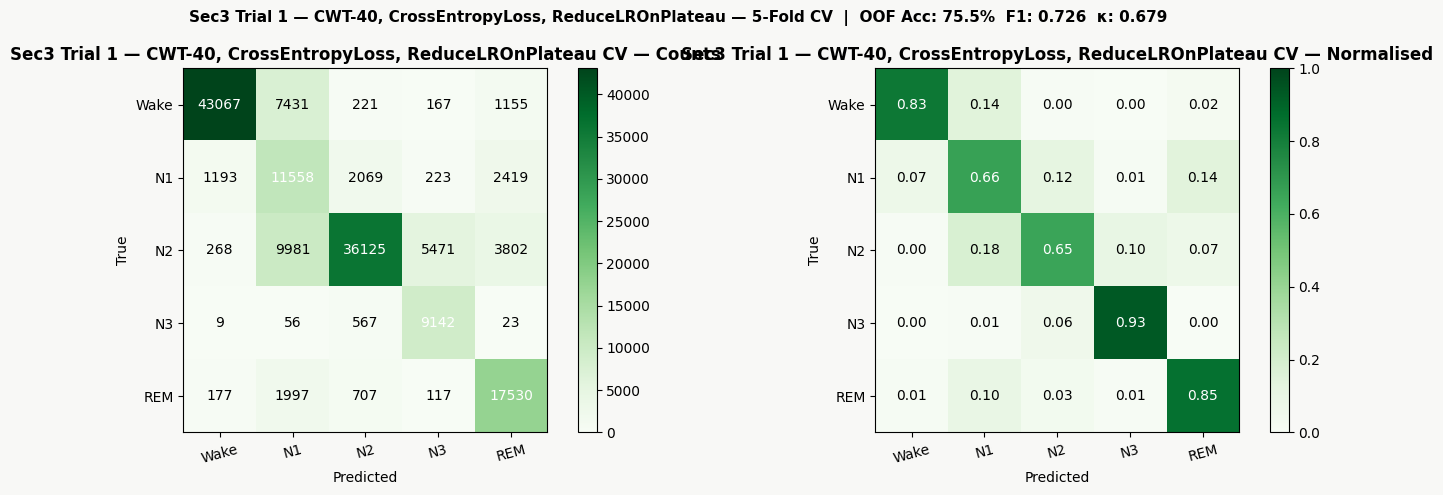

Saved → 05_s3_ce_cv_confusion.png


In [109]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — CV confusion matrix (counts + row-normalised) ──────────────────
cm_cv_s3ce      = confusion_matrix(_oof_true_s3ce_arr, _oof_pred_s3ce_arr,
                                   labels=list(range(N_CLASSES)))
cm_cv_s3ce_norm = cm_cv_s3ce.astype(float) / cm_cv_s3ce.sum(axis=1, keepdims=True)
tnames         = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_cv_s3ce, cm_cv_s3ce_norm],
        ['Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau CV — Counts', 'Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau CV — Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_cv_s3ce_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_cv_s3ce_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — 5-Fold CV  |  '
    f'OOF Acc: {cv_acc_s3ce*100:.1f}%  F1: {cv_f1_s3ce:.3f}  κ: {cv_kappa_s3ce:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_ce_cv_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_ce_cv_confusion.png")


In [110]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Retrain on full training set ────────────────────────────────────
# The CV loop above used 80% of the training data per fold.  Here we retrain
# a fresh model on *all* training sequences so the final weights see every
# available labelled epoch before test evaluation.
print(f"{' Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Full retrain ':─^60}")

# Class-weighted sampler over the complete training split
flat_full      = y_seq_tr.flatten()
cc_full        = np.bincount(flat_full, minlength=N_CLASSES).astype(float)
cw_full        = 1.0 / (cc_full + 1e-6)
sw_full        = np.array([cw_full[y_seq_tr[i]].mean()
                            for i in range(len(y_seq_tr))])
sampler_full   = WeightedRandomSampler(
                     torch.tensor(sw_full, dtype=torch.float32),
                     len(sw_full), replacement=True)
cw_norm_full   = cw_full / cw_full.sum() * N_CLASSES
cw_tensor_full = torch.tensor(cw_norm_full, dtype=torch.float32).to(DEVICE)

train_loader_s3ce = DataLoader(SeqDataset(X_seq_tr_cwt, y_seq_tr),
                                batch_size=32, sampler=sampler_full)
test_loader_s3ce  = DataLoader(SeqDataset(X_seq_te_cwt, y_seq_te),
                                batch_size=32, shuffle=False)

# Fresh model — same architecture and hyper-parameters used in the CV loop
model_s3ce     = WaveletLSTM(input_size=40, proj=64, hidden=128,
                             num_layers=2, num_classes=5,
                             dropout=0.5).to(DEVICE)
criterion_s3ce = nn.CrossEntropyLoss(weight=cw_tensor_full)
optimizer_s3ce = torch.optim.Adam(model_s3ce.parameters(),
                                  lr=1e-3, weight_decay=1e-3)
scheduler_s3ce = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_s3ce, mode="min", factor=0.5, patience=5)

N_EPOCHS_FULL = 50
PATIENCE_FULL = 10
best_val_s3ce, wait_s3ce, best_state_s3ce = float('inf'), 0, None
train_losses_s3ce, val_losses_s3ce       = [], []

print(f"  Epoch  | Train Loss  | Val Loss")
print(f"  ----------------------------------")

for epoch in range(1, N_EPOCHS_FULL + 1):
    model_s3ce.train()
    ep_loss, n_b = 0.0, 0
    for X_b, y_b in train_loader_s3ce:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_s3ce.zero_grad()
        loss = criterion_s3ce(model_s3ce(X_b).reshape(-1, N_CLASSES), y_b.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_s3ce.parameters(), 1.0)
        optimizer_s3ce.step()
        ep_loss += loss.item(); n_b += 1

    model_s3ce.eval()
    vl, nv = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader_s3ce:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            vl += criterion_s3ce(model_s3ce(X_b).reshape(-1, N_CLASSES),
                                 y_b.reshape(-1)).item(); nv += 1

    train_losses_s3ce.append(ep_loss / n_b)
    val_losses_s3ce.append(vl / nv)
    scheduler_s3ce.step(val_losses_s3ce[-1])

    if val_losses_s3ce[-1] < best_val_s3ce:
        best_val_s3ce   = val_losses_s3ce[-1]; wait_s3ce = 0
        best_state_s3ce = {k: v.clone() for k, v in model_s3ce.state_dict().items()}
    else:
        wait_s3ce += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:>5}  | {train_losses_s3ce[-1]:>11.4f} | {val_losses_s3ce[-1]:>9.4f}")
    if wait_s3ce >= PATIENCE_FULL:
        print(f"\n  Early stop at epoch {epoch} (no improvement for {PATIENCE_FULL} epochs)")
        break

model_s3ce.load_state_dict(best_state_s3ce)
torch.save(best_state_s3ce, os.path.join(OUT_DIR, '05_s3_ce_model.pt'))
print(f"\n  Best val loss: {best_val_s3ce:.4f} — weights saved.")


 Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Full retrain 
  Epoch  | Train Loss  | Val Loss
  ----------------------------------
      1  |      0.7935 |    0.8005
      5  |      0.5773 |    0.6142
     10  |      0.5435 |    0.6182
     15  |      0.5297 |    0.5804
     20  |      0.5117 |    0.5601
     25  |      0.5140 |    0.5916
     30  |      0.4900 |    0.5814

  Early stop at epoch 30 (no improvement for 10 epochs)

  Best val loss: 0.5601 — weights saved.


In [111]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Held-out test evaluation + classification report ────────────────
model_s3ce.eval()
preds_list_s3ce, trues_list_s3ce = [], []
with torch.no_grad():
    for X_b, y_b in test_loader_s3ce:
        logits = model_s3ce(X_b.to(DEVICE))
        preds_list_s3ce.append(logits.argmax(dim=-1).cpu().numpy().flatten())
        trues_list_s3ce.append(y_b.numpy().flatten())

y_pred_s3ce = np.concatenate(preds_list_s3ce)
y_true_s3ce = np.concatenate(trues_list_s3ce)

test_acc_s3ce   = accuracy_score(y_true_s3ce, y_pred_s3ce)
test_f1_s3ce    = f1_score(y_true_s3ce, y_pred_s3ce, average='macro')
test_kappa_s3ce = cohen_kappa_score(y_true_s3ce, y_pred_s3ce)

print(f"{' Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Test Results ':═^60}")
print(f"  Accuracy  : {test_acc_s3ce*100:.2f}%")
print(f"  Macro F1  : {test_f1_s3ce:.4f}")
print(f"  Cohen's κ : {test_kappa_s3ce:.4f}  ({kappa_label(test_kappa_s3ce)})")
print()
tnames = [STAGE_NAMES[s] for s in range(N_CLASSES)]
print(classification_report(y_true_s3ce, y_pred_s3ce, target_names=tnames, digits=4))


 Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Test Results 
  Accuracy  : 77.28%
  Macro F1  : 0.7459
  Cohen's κ : 0.7024  (Substantial)

              precision    recall  f1-score   support

        Wake     0.9628    0.8147    0.8826     12122
          N1     0.4007    0.6134    0.4847      4048
          N2     0.8882    0.7140    0.7916     13481
          N3     0.7503    0.9192    0.8262      3242
         REM     0.6569    0.8585    0.7443      5307

    accuracy                         0.7728     38200
   macro avg     0.7317    0.7839    0.7459     38200
weighted avg     0.8163    0.7728    0.7843     38200



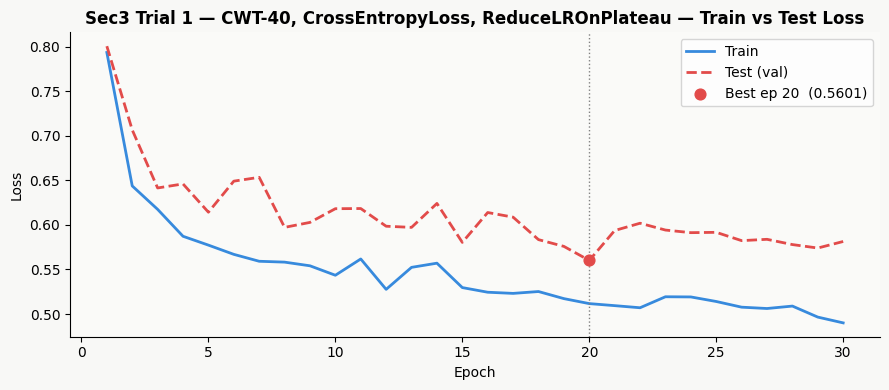

Saved → 05_s3_ce_train_test_loss.png


In [112]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Train vs test loss (full retrain run) ──────────────────────────
ep_range = range(1, len(train_losses_s3ce) + 1)
best_ep  = int(np.argmin(val_losses_s3ce))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f8f8f6'); ax.set_facecolor('#fafaf8')

ax.plot(ep_range, train_losses_s3ce, color='#378ADD', linewidth=2, label='Train')
ax.plot(ep_range, val_losses_s3ce,   color='#E24B4A', linewidth=2,
        linestyle='--', label='Test (val)')
ax.axvline(best_ep + 1, color='gray', linewidth=1, linestyle=':')
ax.scatter(best_ep + 1, val_losses_s3ce[best_ep], color='#E24B4A', zorder=5, s=60,
           label=f'Best ep {best_ep+1}  ({val_losses_s3ce[best_ep]:.4f})')

ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Train vs Test Loss', fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_ce_train_test_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_ce_train_test_loss.png")


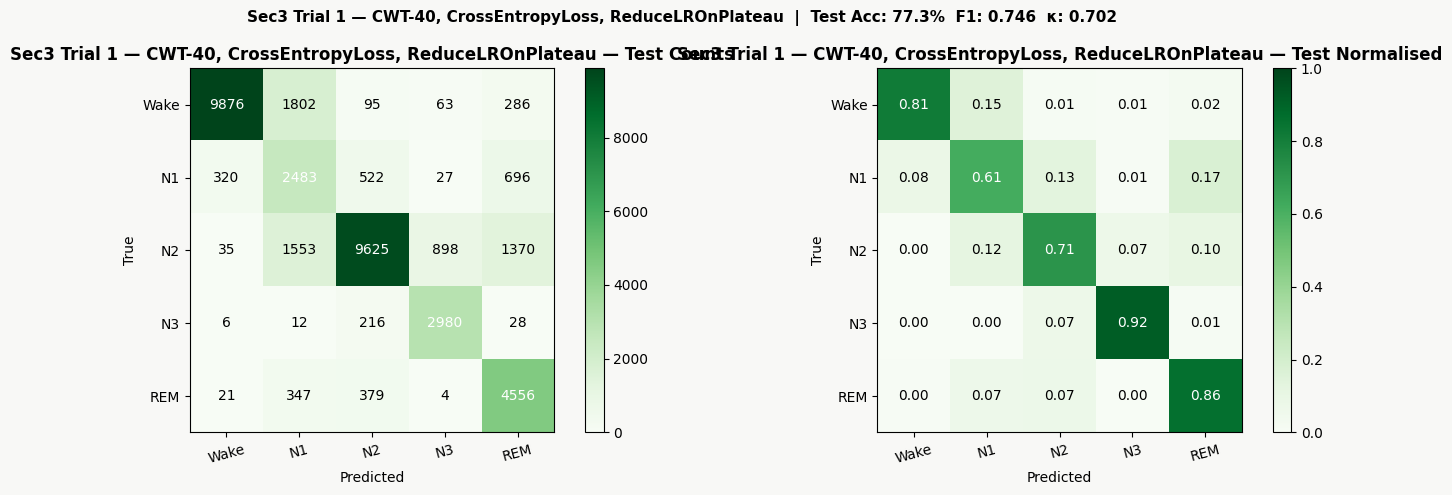

Saved → 05_s3_ce_test_confusion.png


In [113]:
# ── Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Test confusion matrix (counts + row-normalised) ────────────────
cm_s3ce      = confusion_matrix(y_true_s3ce, y_pred_s3ce, labels=list(range(N_CLASSES)))
cm_s3ce_norm = cm_s3ce.astype(float) / cm_s3ce.sum(axis=1, keepdims=True)
tnames      = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_s3ce, cm_s3ce_norm],
        ['Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Test Counts', 'Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau — Test Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_s3ce_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_s3ce_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Sec3 Trial 1 — CWT-40, CrossEntropyLoss, ReduceLROnPlateau  |  '
    f'Test Acc: {test_acc_s3ce*100:.1f}%  F1: {test_f1_s3ce:.3f}  κ: {test_kappa_s3ce:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_ce_test_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_ce_test_confusion.png")


### Trial 2 - CWT-40, FocalLoss(γ=2), ReduceLROnPlateau

In [ ]:
# ── Section 3 | Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — 5-Fold Stratified Cross-Validation ──────────────────
# Fresh storage for this trial; all variables are prefixed 's3fl_' to avoid
# collisions with other trials running in the same kernel session.

class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017).  gamma=0 recovers weighted cross-entropy.
    Downweights well-classified examples so training focuses on hard cases —
    particularly helpful for the minority N1 class.
    """
    def __init__(self, weight=None, gamma: float = 2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets,
                               weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        return ((1.0 - pt) ** self.gamma * ce).mean()


N_FOLDS_CV  = 5
N_EPOCHS_CV = 50
LR_CV       = 1e-3
PATIENCE_CV = 10
SEQ_LEN     = 25   # 25-epoch context window (unchanged throughout)

cv_s3fl_fold_accs,   cv_s3fl_fold_f1s,  cv_s3fl_fold_kappas  = [], [], []
cv_s3fl_fold_tloss,  cv_s3fl_fold_vloss                      = [], []
_oof_pred_s3fl,      _oof_true_s3fl                          = [], []

# Use the middle epoch of each sequence for stratification
y_mid_s3fl = y_seq_tr[:, SEQ_LEN // 2]
skf_s3fl   = StratifiedKFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=42)

print(f"────────────────────────────────────────────────────────────")
print(f"  Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau  —  {N_FOLDS_CV}-Fold CV")
print(f"  LR=1e-3  |  dropout=0.5  |  wd=1e-3  |  epochs≤50")
print(f"────────────────────────────────────────────────────────────")
print(f"  {'{}'.format('Fold'):>5} | {'{}'.format('Acc'):>7} | "
      f"{'{}'.format('Macro F1'):>9} | {'{}'.format(chr(954)):>7}")
print(f"  {'-'*38}")

for fold, (tr_idx, val_idx) in enumerate(skf_s3fl.split(X_seq_tr_cwt, y_mid_s3fl)):

    # ── Fold data ─────────────────────────────────────────────────────────────
    X_tr_f,  X_val_f = X_seq_tr_cwt[tr_idx],  X_seq_tr_cwt[val_idx]
    y_tr_f,  y_val_f = y_seq_tr[tr_idx], y_seq_tr[val_idx]

    # Inverse-frequency class weights + weighted random sampler
    flat_f      = y_tr_f.flatten()
    cc_f        = np.bincount(flat_f, minlength=N_CLASSES).astype(float)
    cw_f        = 1.0 / (cc_f + 1e-6)
    sw_f        = np.array([cw_f[y_tr_f[i]].mean() for i in range(len(y_tr_f))])
    sampler_f   = WeightedRandomSampler(
                      torch.tensor(sw_f, dtype=torch.float32),
                      len(sw_f), replacement=True)
    cw_norm_f   = cw_f / cw_f.sum() * N_CLASSES
    cw_tensor_f = torch.tensor(cw_norm_f, dtype=torch.float32).to(DEVICE)

    loader_tr_f  = DataLoader(SeqDataset(X_tr_f,  y_tr_f),
                               batch_size=32, sampler=sampler_f)
    loader_val_f = DataLoader(SeqDataset(X_val_f, y_val_f),
                               batch_size=32, shuffle=False)

    # ── Fresh model + optimiser for this fold ─────────────────────────────────
    mdl_f  = WaveletLSTM(input_size=40, proj=64, hidden=128,
                          num_layers=2, num_classes=5, dropout=0.5).to(DEVICE)
    crit_f = FocalLoss(weight=cw_tensor_f, gamma=2.0).to(DEVICE)
    opt_f  = torch.optim.Adam(mdl_f.parameters(), lr=LR_CV, weight_decay=1e-3)
    sched_f = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_f, mode="min", factor=0.5, patience=5)

    best_val_f, wait_f, best_st_f = float('inf'), 0, None
    tl_hist_f, vl_hist_f = [], []   # per-epoch loss history for this fold

    # ── Training loop ──────────────────────────────────────────────────────────
    for epoch in range(1, N_EPOCHS_CV + 1):
        mdl_f.train()
        ep_loss, n_b = 0.0, 0
        for X_b, y_b in loader_tr_f:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_f.zero_grad()
            out  = mdl_f(X_b).reshape(-1, N_CLASSES)
            loss = crit_f(out, y_b.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(mdl_f.parameters(), 1.0)
            opt_f.step()
            ep_loss += loss.item(); n_b += 1

        mdl_f.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in loader_val_f:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vl += crit_f(mdl_f(X_b).reshape(-1, N_CLASSES),
                             y_b.reshape(-1)).item(); nv += 1

        tl_hist_f.append(ep_loss / n_b)
        vl_hist_f.append(vl / nv)
        sched_f.step(vl_hist_f[-1])   # ReduceLROnPlateau monitors val loss

        if vl_hist_f[-1] < best_val_f:
            best_val_f = vl_hist_f[-1]; wait_f = 0
            best_st_f  = {k: v.clone() for k, v in mdl_f.state_dict().items()}
        else:
            wait_f += 1
        if wait_f >= PATIENCE_CV:
            break

    # ── Store per-fold loss curves (after all epochs) ─────────────────────────
    cv_s3fl_fold_tloss.append(tl_hist_f)
    cv_s3fl_fold_vloss.append(vl_hist_f)

    # ── Evaluate on the held-out fold ──────────────────────────────────────────
    mdl_f.load_state_dict(best_st_f)
    mdl_f.eval()
    preds_f, trues_f = [], []
    with torch.no_grad():
        for X_b, y_b in loader_val_f:
            p = mdl_f(X_b.to(DEVICE)).argmax(dim=-1)
            preds_f.append(p.cpu().numpy().flatten())
            trues_f.append(y_b.numpy().flatten())
    preds_f = np.concatenate(preds_f)
    trues_f = np.concatenate(trues_f)

    acc_f   = accuracy_score(trues_f, preds_f)
    f1_f    = f1_score(trues_f, preds_f, average='macro')
    kappa_f = cohen_kappa_score(trues_f, preds_f)

    cv_s3fl_fold_accs.append(acc_f);   cv_s3fl_fold_f1s.append(f1_f)
    cv_s3fl_fold_kappas.append(kappa_f)
    _oof_pred_s3fl.extend(preds_f.tolist())
    _oof_true_s3fl.extend(trues_f.tolist())

    print(f"  {fold+1:>5} | {acc_f*100:>6.2f}% | {f1_f:>9.4f} | {kappa_f:>7.4f}")

print(f"  {'-'*38}")
print(f"  Mean  | {np.mean(cv_s3fl_fold_accs)*100:>6.2f}% | "
      f"{np.mean(cv_s3fl_fold_f1s):>9.4f} | {np.mean(cv_s3fl_fold_kappas):>7.4f}")
print(f"  ±Std  | {np.std(cv_s3fl_fold_accs)*100:>6.2f}%   | "
      f"{np.std(cv_s3fl_fold_f1s):>9.4f} | {np.std(cv_s3fl_fold_kappas):>7.4f}")

# Aggregate OOF arrays for the CV-level confusion matrix and classification report
_oof_pred_s3fl_arr = np.array(_oof_pred_s3fl, dtype=np.int64)
_oof_true_s3fl_arr = np.array(_oof_true_s3fl, dtype=np.int64)


────────────────────────────────────────────────────────────
  Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau  —  5-Fold CV
  LR=1e-3  |  dropout=0.5  |  wd=1e-3  |  epochs≤50
────────────────────────────────────────────────────────────
   Fold |     Acc |  Macro F1 |       κ
  --------------------------------------
      1 |  63.80% |    0.6249 |  0.5479
      2 |  61.70% |    0.6182 |  0.5261
      3 |  61.01% |    0.6033 |  0.5157
      4 |  61.40% |    0.6150 |  0.5241
      5 |  61.96% |    0.6169 |  0.5277
  --------------------------------------
  Mean  |  61.97% |    0.6157 |  0.5283
  ±Std  |   0.97%   |    0.0070 |  0.0106


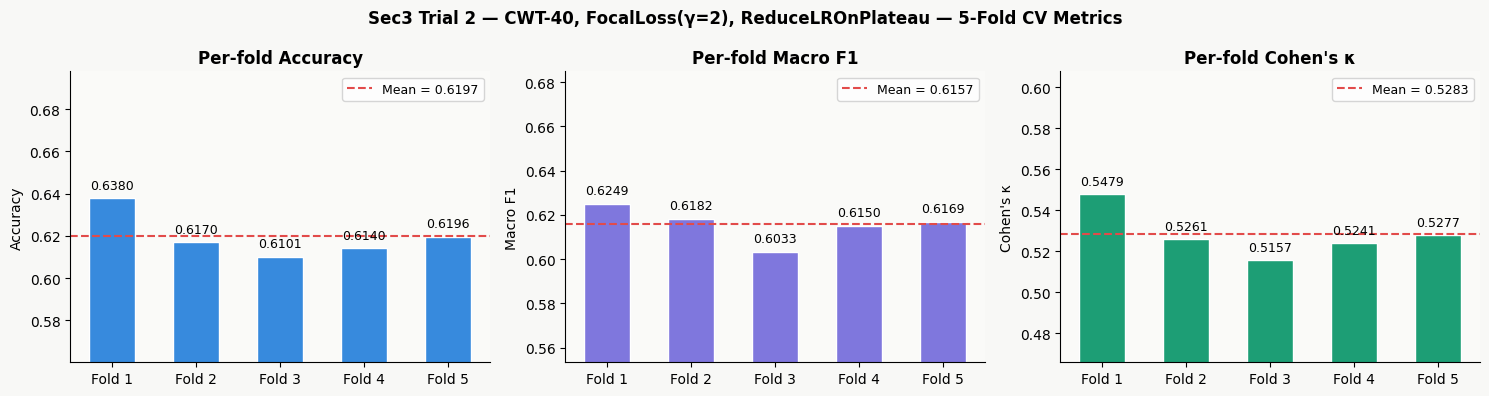

Saved → 05_s3_fl_cv_fold_metrics.png


In [115]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Per-fold bar charts: Accuracy, Macro F1, Cohen's κ ─────────────
fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS_CV)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#f8f8f6')

for ax, (vals, metric_name, color) in zip(axes, [
    (cv_s3fl_fold_accs,   'Accuracy',   '#378ADD'),
    (cv_s3fl_fold_f1s,    'Macro F1',   '#7F77DD'),
    (cv_s3fl_fold_kappas, "Cohen's κ",  '#1D9E75'),
]):
    ax.set_facecolor('#fafaf8')
    bars   = ax.bar(fold_labels, vals, color=color, edgecolor='white', width=0.55)
    mean_v = np.mean(vals)
    ax.axhline(mean_v, color='#E24B4A', linewidth=1.5,
               linestyle='--', label=f'Mean = {mean_v:.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Per-fold {metric_name}', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.06))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — 5-Fold CV Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_fl_cv_fold_metrics.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_fl_cv_fold_metrics.png")


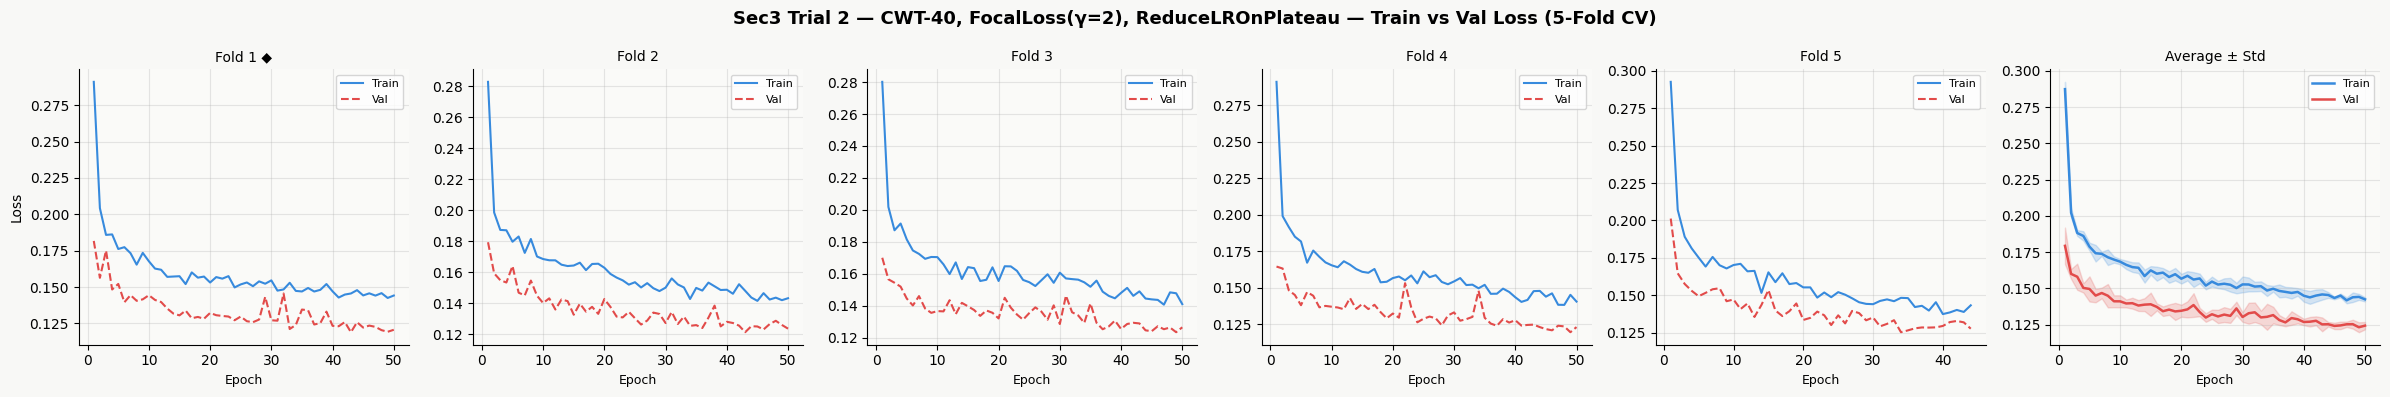

Saved → 05_s3_fl_cv_fold_loss.png


In [116]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Train vs Val loss curves (5 folds + mean±std panel) ────────────
def _pad(lst, length):
    """Right-pad a list with its last value so curves align to the same length."""
    return lst + [lst[-1]] * (length - len(lst))

best_fold_s3fl = int(np.argmin([h[-1] for h in cv_s3fl_fold_vloss])) + 1
n_panels      = N_FOLDS_CV + 1   # one per fold + one average panel

fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
fig.patch.set_facecolor('#f8f8f6')

for i, ax in enumerate(axes[:N_FOLDS_CV]):
    marker = ' ◆' if (i + 1) == best_fold_s3fl else ''
    ep_range = range(1, len(cv_s3fl_fold_tloss[i]) + 1)
    ax.plot(ep_range, cv_s3fl_fold_tloss[i], color='#378ADD', linewidth=1.5, label='Train')
    ax.plot(ep_range, cv_s3fl_fold_vloss[i], color='#E24B4A', linewidth=1.5,
            linestyle='--', label='Val')
    ax.set_title(f'Fold {i+1}{marker}', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9)
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_facecolor('#fafaf8')
    ax.spines[['top', 'right']].set_visible(False)

# Average ± std panel
ax_avg    = axes[-1]
max_ep    = max(len(h) for h in cv_s3fl_fold_tloss)
train_mat = np.array([_pad(h, max_ep) for h in cv_s3fl_fold_tloss])
val_mat   = np.array([_pad(h, max_ep) for h in cv_s3fl_fold_vloss])
ep_arr    = np.arange(1, max_ep + 1)

for mat, color, lbl in [(train_mat, '#378ADD', 'Train'), (val_mat, '#E24B4A', 'Val')]:
    m, s = mat.mean(axis=0), mat.std(axis=0)
    ax_avg.plot(ep_arr, m, color=color, linewidth=1.8, label=lbl)
    ax_avg.fill_between(ep_arr, m - s, m + s, alpha=0.2, color=color)

ax_avg.set_title('Average ± Std', fontsize=10)
ax_avg.set_xlabel('Epoch', fontsize=9)
ax_avg.legend(fontsize=8); ax_avg.grid(alpha=0.3); ax_avg.set_facecolor('#fafaf8')
ax_avg.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Train vs Val Loss (5-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_fl_cv_fold_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_fl_cv_fold_loss.png")


In [117]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — CV summary + OOF classification report ─────────────────────────
cv_acc_s3fl   = accuracy_score(_oof_true_s3fl_arr, _oof_pred_s3fl_arr)
cv_f1_s3fl    = f1_score(_oof_true_s3fl_arr, _oof_pred_s3fl_arr, average='macro')
cv_kappa_s3fl = cohen_kappa_score(_oof_true_s3fl_arr, _oof_pred_s3fl_arr)

print(f"{' Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — CV Summary ':═^65}")
print(f"  OOF Accuracy  : {cv_acc_s3fl*100:.2f}%")
print(f"  OOF Macro F1  : {cv_f1_s3fl:.4f}")
print(f"  OOF Cohen's κ : {cv_kappa_s3fl:.4f}  ({kappa_label(cv_kappa_s3fl)})")
print(f"  Per-fold Acc  : {np.mean(cv_s3fl_fold_accs)*100:.2f}%"
      f" ± {np.std(cv_s3fl_fold_accs)*100:.2f}%")
print(f"  Per-fold F1   : {np.mean(cv_s3fl_fold_f1s):.4f}"
      f" ± {np.std(cv_s3fl_fold_f1s):.4f}")
print(f"  Per-fold κ    : {np.mean(cv_s3fl_fold_kappas):.4f}"
      f" ± {np.std(cv_s3fl_fold_kappas):.4f}")
print()
tnames = [STAGE_NAMES[s] for s in range(5)]
print(classification_report(_oof_true_s3fl_arr, _oof_pred_s3fl_arr,
                             target_names=tnames, digits=4))


 Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — CV Summary 
  OOF Accuracy  : 61.97%
  OOF Macro F1  : 0.6159
  OOF Cohen's κ : 0.5283  (Moderate)
  Per-fold Acc  : 61.97% ± 0.97%
  Per-fold F1   : 0.6157 ± 0.0070
  Per-fold κ    : 0.5283 ± 0.0106

              precision    recall  f1-score   support

        Wake     0.9856    0.6995    0.8183     52041
          N1     0.2719    0.7749    0.4026     17462
          N2     0.9542    0.3468    0.5087     55647
          N3     0.4505    0.9748    0.6162      9797
         REM     0.6423    0.8560    0.7339     20528

    accuracy                         0.6197    155475
   macro avg     0.6609    0.7304    0.6159    155475
weighted avg     0.8152    0.6197    0.6369    155475



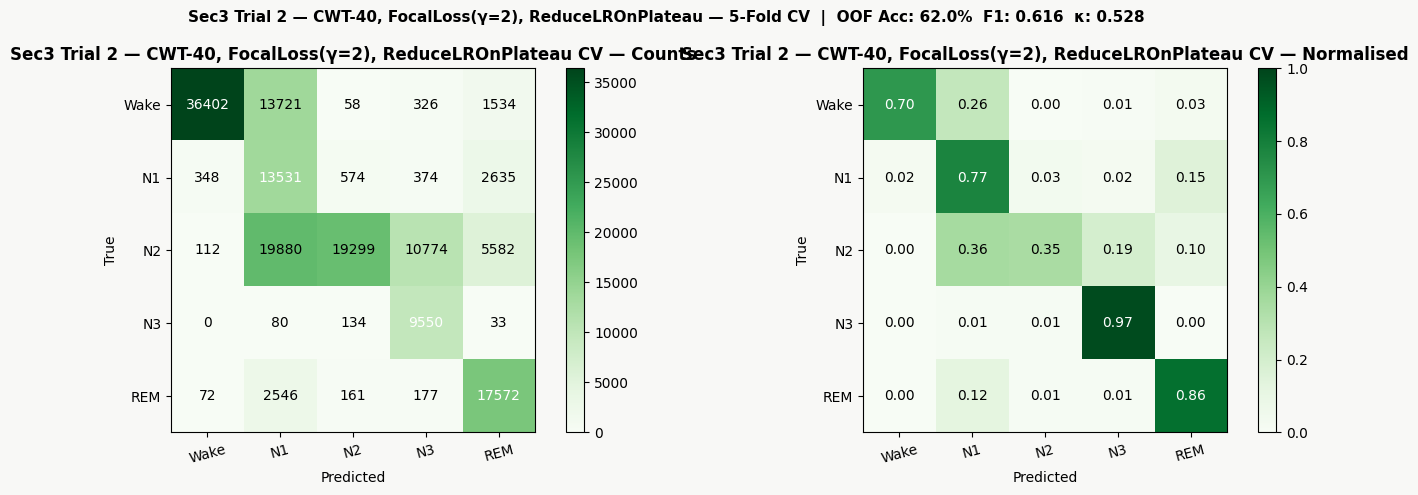

Saved → 05_s3_fl_cv_confusion.png


In [118]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — CV confusion matrix (counts + row-normalised) ──────────────────
cm_cv_s3fl      = confusion_matrix(_oof_true_s3fl_arr, _oof_pred_s3fl_arr,
                                   labels=list(range(N_CLASSES)))
cm_cv_s3fl_norm = cm_cv_s3fl.astype(float) / cm_cv_s3fl.sum(axis=1, keepdims=True)
tnames         = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_cv_s3fl, cm_cv_s3fl_norm],
        ['Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau CV — Counts', 'Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau CV — Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_cv_s3fl_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_cv_s3fl_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — 5-Fold CV  |  '
    f'OOF Acc: {cv_acc_s3fl*100:.1f}%  F1: {cv_f1_s3fl:.3f}  κ: {cv_kappa_s3fl:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_fl_cv_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_fl_cv_confusion.png")


In [119]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Retrain on full training set ────────────────────────────────────
# The CV loop above used 80% of the training data per fold.  Here we retrain
# a fresh model on *all* training sequences so the final weights see every
# available labelled epoch before test evaluation.
print(f"{' Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Full retrain ':─^60}")

# Class-weighted sampler over the complete training split
flat_full      = y_seq_tr.flatten()
cc_full        = np.bincount(flat_full, minlength=N_CLASSES).astype(float)
cw_full        = 1.0 / (cc_full + 1e-6)
sw_full        = np.array([cw_full[y_seq_tr[i]].mean()
                            for i in range(len(y_seq_tr))])
sampler_full   = WeightedRandomSampler(
                     torch.tensor(sw_full, dtype=torch.float32),
                     len(sw_full), replacement=True)
cw_norm_full   = cw_full / cw_full.sum() * N_CLASSES
cw_tensor_full = torch.tensor(cw_norm_full, dtype=torch.float32).to(DEVICE)

train_loader_s3fl = DataLoader(SeqDataset(X_seq_tr_cwt, y_seq_tr),
                                batch_size=32, sampler=sampler_full)
test_loader_s3fl  = DataLoader(SeqDataset(X_seq_te_cwt, y_seq_te),
                                batch_size=32, shuffle=False)

# Fresh model — same architecture and hyper-parameters used in the CV loop
model_s3fl     = WaveletLSTM(input_size=40, proj=64, hidden=128,
                             num_layers=2, num_classes=5,
                             dropout=0.5).to(DEVICE)
criterion_s3fl = FocalLoss(weight=cw_tensor_full, gamma=2.0).to(DEVICE)
optimizer_s3fl = torch.optim.Adam(model_s3fl.parameters(),
                                  lr=1e-3, weight_decay=1e-3)
scheduler_s3fl = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_s3fl, mode="min", factor=0.5, patience=5)

N_EPOCHS_FULL = 50
PATIENCE_FULL = 10
best_val_s3fl, wait_s3fl, best_state_s3fl = float('inf'), 0, None
train_losses_s3fl, val_losses_s3fl       = [], []

print(f"  Epoch  | Train Loss  | Val Loss")
print(f"  ----------------------------------")

for epoch in range(1, N_EPOCHS_FULL + 1):
    model_s3fl.train()
    ep_loss, n_b = 0.0, 0
    for X_b, y_b in train_loader_s3fl:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_s3fl.zero_grad()
        loss = criterion_s3fl(model_s3fl(X_b).reshape(-1, N_CLASSES), y_b.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_s3fl.parameters(), 1.0)
        optimizer_s3fl.step()
        ep_loss += loss.item(); n_b += 1

    model_s3fl.eval()
    vl, nv = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader_s3fl:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            vl += criterion_s3fl(model_s3fl(X_b).reshape(-1, N_CLASSES),
                                 y_b.reshape(-1)).item(); nv += 1

    train_losses_s3fl.append(ep_loss / n_b)
    val_losses_s3fl.append(vl / nv)
    scheduler_s3fl.step(val_losses_s3fl[-1])

    if val_losses_s3fl[-1] < best_val_s3fl:
        best_val_s3fl   = val_losses_s3fl[-1]; wait_s3fl = 0
        best_state_s3fl = {k: v.clone() for k, v in model_s3fl.state_dict().items()}
    else:
        wait_s3fl += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:>5}  | {train_losses_s3fl[-1]:>11.4f} | {val_losses_s3fl[-1]:>9.4f}")
    if wait_s3fl >= PATIENCE_FULL:
        print(f"\n  Early stop at epoch {epoch} (no improvement for {PATIENCE_FULL} epochs)")
        break

model_s3fl.load_state_dict(best_state_s3fl)
torch.save(best_state_s3fl, os.path.join(OUT_DIR, '05_s3_fl_model.pt'))
print(f"\n  Best val loss: {best_val_s3fl:.4f} — weights saved.")


 Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Full retrain 
  Epoch  | Train Loss  | Val Loss
  ----------------------------------
      1  |      0.2671 |    0.1991
      5  |      0.1794 |    0.1515
     10  |      0.1631 |    0.1563
     15  |      0.1599 |    0.1545
     20  |      0.1541 |    0.1372
     25  |      0.1479 |    0.1424
     30  |      0.1507 |    0.1307
     35  |      0.1480 |    0.1520
     40  |      0.1457 |    0.1327
     45  |      0.1435 |    0.1337

  Early stop at epoch 49 (no improvement for 10 epochs)

  Best val loss: 0.1295 — weights saved.


In [120]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Held-out test evaluation + classification report ────────────────
model_s3fl.eval()
preds_list_s3fl, trues_list_s3fl = [], []
with torch.no_grad():
    for X_b, y_b in test_loader_s3fl:
        logits = model_s3fl(X_b.to(DEVICE))
        preds_list_s3fl.append(logits.argmax(dim=-1).cpu().numpy().flatten())
        trues_list_s3fl.append(y_b.numpy().flatten())

y_pred_s3fl = np.concatenate(preds_list_s3fl)
y_true_s3fl = np.concatenate(trues_list_s3fl)

test_acc_s3fl   = accuracy_score(y_true_s3fl, y_pred_s3fl)
test_f1_s3fl    = f1_score(y_true_s3fl, y_pred_s3fl, average='macro')
test_kappa_s3fl = cohen_kappa_score(y_true_s3fl, y_pred_s3fl)

print(f"{' Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Test Results ':═^60}")
print(f"  Accuracy  : {test_acc_s3fl*100:.2f}%")
print(f"  Macro F1  : {test_f1_s3fl:.4f}")
print(f"  Cohen's κ : {test_kappa_s3fl:.4f}  ({kappa_label(test_kappa_s3fl)})")
print()
tnames = [STAGE_NAMES[s] for s in range(N_CLASSES)]
print(classification_report(y_true_s3fl, y_pred_s3fl, target_names=tnames, digits=4))


 Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Test Results 
  Accuracy  : 60.14%
  Macro F1  : 0.6173
  Cohen's κ : 0.5124  (Moderate)

              precision    recall  f1-score   support

        Wake     0.9884    0.5963    0.7438     12122
          N1     0.2492    0.8036    0.3804      4048
          N2     0.9508    0.3544    0.5164     13481
          N3     0.5850    0.9543    0.7254      3242
         REM     0.6147    0.8707    0.7207      5307

    accuracy                         0.6014     38200
   macro avg     0.6776    0.7159    0.6173     38200
weighted avg     0.8107    0.6014    0.6203     38200



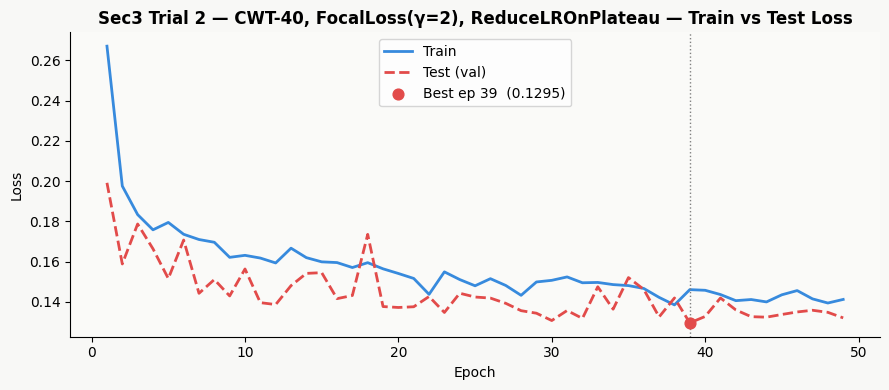

Saved → 05_s3_fl_train_test_loss.png


In [121]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Train vs test loss (full retrain run) ──────────────────────────
ep_range = range(1, len(train_losses_s3fl) + 1)
best_ep  = int(np.argmin(val_losses_s3fl))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f8f8f6'); ax.set_facecolor('#fafaf8')

ax.plot(ep_range, train_losses_s3fl, color='#378ADD', linewidth=2, label='Train')
ax.plot(ep_range, val_losses_s3fl,   color='#E24B4A', linewidth=2,
        linestyle='--', label='Test (val)')
ax.axvline(best_ep + 1, color='gray', linewidth=1, linestyle=':')
ax.scatter(best_ep + 1, val_losses_s3fl[best_ep], color='#E24B4A', zorder=5, s=60,
           label=f'Best ep {best_ep+1}  ({val_losses_s3fl[best_ep]:.4f})')

ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Train vs Test Loss', fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_fl_train_test_loss.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_fl_train_test_loss.png")


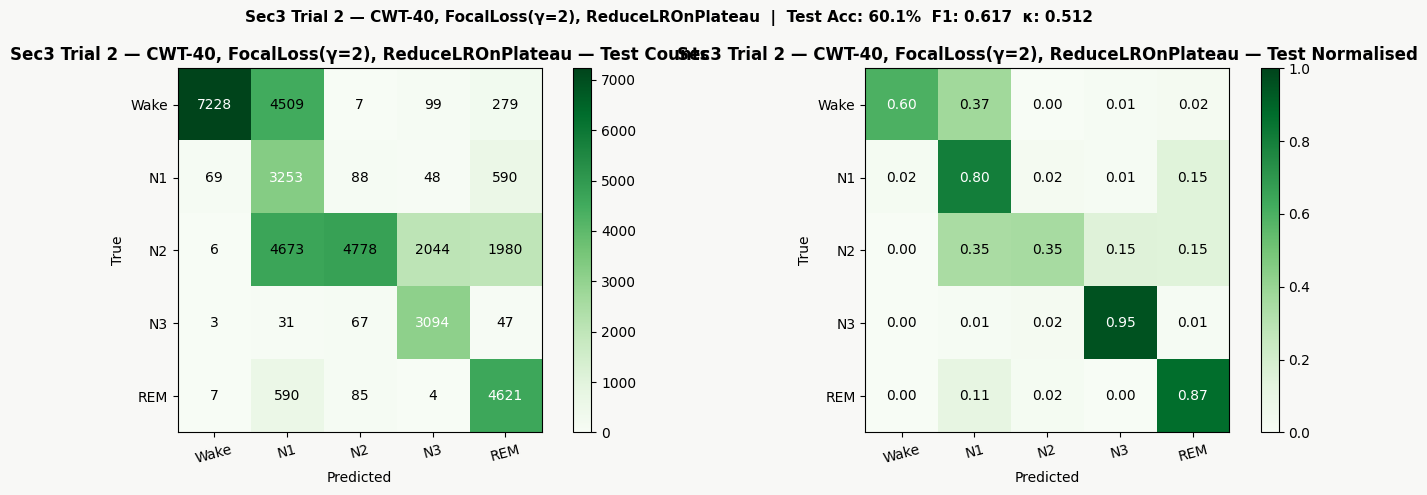

Saved → 05_s3_fl_test_confusion.png


In [122]:
# ── Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Test confusion matrix (counts + row-normalised) ────────────────
cm_s3fl      = confusion_matrix(y_true_s3fl, y_pred_s3fl, labels=list(range(N_CLASSES)))
cm_s3fl_norm = cm_s3fl.astype(float) / cm_s3fl.sum(axis=1, keepdims=True)
tnames      = [STAGE_NAMES[s] for s in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt_fn in zip(
        axes,
        [cm_s3fl, cm_s3fl_norm],
        ['Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Test Counts', 'Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau — Test Normalised'],
        [lambda v: str(int(v)), lambda v: f'{v:.2f}']):
    vmax = 1.0 if data is cm_s3fl_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(tnames, rotation=15); ax.set_yticklabels(tnames)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            ax.text(c, r, fmt_fn(data[r, c]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_s3fl_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'Sec3 Trial 2 — CWT-40, FocalLoss(γ=2), ReduceLROnPlateau  |  '
    f'Test Acc: {test_acc_s3fl*100:.1f}%  F1: {test_f1_s3fl:.3f}  κ: {test_kappa_s3fl:.3f}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_s3_fl_test_confusion.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved → 05_s3_fl_test_confusion.png")
